<a href="https://colab.research.google.com/github/ConorMesser/stats_305c/blob/main/Latent_Analsyis_model_testing2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install numpyro

In [ ]:
# check this if running on GPU
import jax
jax.default_backend()

'gpu'

In [ ]:
jax.devices()

[CudaDevice(id=0)]

In [ ]:
# Use 32-point precision
jax.config.update("jax_enable_x64", False)

In [ ]:
# Set up file system
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
# download the git repo
!git clone https://github.com/ConorMesser/stats_305c.git

fatal: destination path 'stats_305c' already exists and is not an empty directory.


In [ ]:
!cd stats_305c/; git pull

Already up to date.


In [ ]:
import sys
sys.path.insert(0, './stats_305c') # Add the stats_305c directory to the Python path

#!pip install --upgrade --force-reinstall pymc arviz

import stats_305c.pmf_model
import importlib

importlib.reload(stats_305c.pmf_model)

<module 'stats_305c.pmf_model' from '/content/stats_305c/pmf_model.py'>

In [ ]:
from stats_305c.pmf_model import Hybrid_PMF, compute_metrics, split_random_mask, split_holdout_peptides

In [ ]:

import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import os
import arviz as az
from sklearn.preprocessing import StandardScaler
import pandas as pd
import xarray as xr
import scipy.stats as stats
from pymc.sampling.jax import sample_numpyro_nuts



# Load and Process Data

In [ ]:
file_path = '/content/drive/MyDrive/STATS305c/' # Lauren
#file_path = '/content/drive/MyDrive/Courses/STATS305c/' # Conor

mic_file = pathlib.Path(os.path.join(file_path, 'data', 'MIC_data_cleaned.csv'))
cp_file = pathlib.Path(os.path.join(file_path, 'data', 'all_chem_phys_features.txt'))
embed_file = pathlib.Path(os.path.join(file_path, 'embeddings', 'all_embeddings.tsv'))

full_mic_data = pd.read_csv(mic_file)
all_chem_phys = pd.read_csv(cp_file, sep='\t', index_col=0)
all_chem_phys.index.name = 'Peptide ID'
all_embeddings = pd.read_csv(embed_file, sep='\t', index_col=0)
all_embeddings.index.name = 'Peptide ID'

# Initialize the scaler
scaler = StandardScaler()

# Extract the relevant physical chemistry features (columns 1 to 12)
pc_features = all_chem_phys.iloc[:, 1:13]

# Fit the scaler (calculates mean and std) and transform the data
pc_normalized_array = scaler.fit_transform(pc_features)

# Create a copy of the original all_chem_phys DataFrame to store normalized values
pc_normalized = all_chem_phys.copy()

# Explicitly convert the target columns in pc_normalized to float
# to avoid TypeError during assignment of the float array.
for col_name in pc_features.columns:
    pc_normalized[col_name] = pc_normalized[col_name].astype(float)

# Now assign the normalized array to the float-type columns
pc_normalized.iloc[:, 1:13] = pc_normalized_array

TypeError: Invalid value '[-1.14303094 -2.58278073 -0.71110601 ... -0.56713103 -0.27918107
 -0.13520609]' for dtype 'int64'

Components for 90% variance: 62
Components for 95% variance: 139
Components for 99% variance: 519


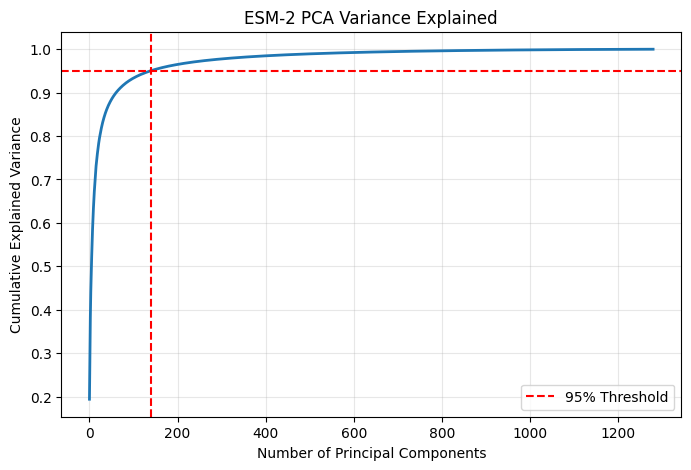

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import joblib

# Assuming your esm_df has the peptide IDs as the index
# and the 1280 features as the columns.
esm_features = all_embeddings.values

# 1. Standardize the features (Crucial before PCA)
scaler = StandardScaler()
esm_scaled = scaler.fit_transform(esm_features)

# 2. Fit the full PCA to analyze the variance
pca_full = PCA()
pca_full.fit(esm_scaled)

# 3. Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# 4. Find the exact number of components for your thresholds
k_90 = np.argmax(cumulative_variance >= 0.90) + 1
k_95 = np.argmax(cumulative_variance >= 0.95) + 1
k_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"Components for 90% variance: {k_90}")
print(f"Components for 95% variance: {k_95}")
print(f"Components for 99% variance: {k_99}")

# Plotting the variance curve is always good for the final report
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.axvline(x=k_95, color='r', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('ESM-2 PCA Variance Explained')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:

pca_final = PCA(n_components=k_95)
esm_pca_transformed = pca_final.fit_transform(esm_scaled)

# 2. Convert back to a DataFrame to keep your peptide index intact
esm_pca_df = pd.DataFrame(
    esm_pca_transformed,
    index=all_embeddings.index,
    columns=[f"PC_{i+1}" for i in range(k_95)]
)

In [ ]:
peptides_w_data = list(set(full_mic_data['Peptide ID']) & set(all_chem_phys.index))

has_data = full_mic_data[full_mic_data['Peptide ID'].isin(peptides_w_data)] #.drop_duplicates(['Peptide ID', 'Target Species']) # no need to drop duplicates on Peptide/species

# if we want test data (only a few species, no duplicates)
# top_species = has_data.groupby('Target Species').size().sort_values(ascending=False).iloc[:20].index

# Filter species by number of observations
top_species_df = has_data.groupby('Target Species').size()
top_species = top_species_df[top_species_df > 10].index  # Lower with hierarchical model?

# Get MIC values
test_mic = has_data[has_data['Target Species'].isin(top_species)].dropna(subset=['Peptide ID', 'Target Species', 'Activity_uM', 'Activity_low_uM'])
test_mic['mic'] = np.log2(test_mic['Activity_uM'].astype(float))
test_mic['mic_low'] = np.log2(test_mic['Activity_low_uM'].astype(float))  # for tobit model (lower estimate of true observation)

# process the censored values
# test_mic['censored_high']

# subtract global mean
# global_mean = np.concatenate([test_mic['mic'], test_mic['mic_low']]).mean()
mic_scaler = StandardScaler()
test_mic['mic_transformed'] = mic_scaler.fit_transform(test_mic[['mic']].values)

# how to transorm mic_low???
# test_mic['mic_low_transformed'] = test_mic['mic_low'] - global_mean

test_mic.shape

(79818, 27)

In [ ]:
# Combine all splits
combined_df = pd.concat(
    [
        train_df,
        random_test,
        hold_peptides_test
    ],
    ignore_index=True
)

print(
    "Unique peptides in full dataset:",
    test_mic["Peptide ID"].nunique()
)

print(
    "Unique target species in full dataset:",
    test_mic["Target Species"].nunique()
)

NameError: name 'train_df' is not defined

In [ ]:
print('Num peptides:', test_mic['Peptide ID'].nunique())

In [ ]:
test_mic.groupby('Peptide ID')['Target Species'].nunique().plot.hist(bins=40)

<Axes: ylabel='Frequency'>

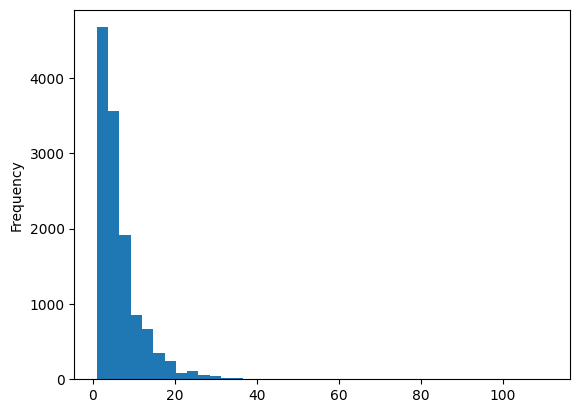

In [ ]:
test_mic['Peptide ID'].value_counts().plot.hist(bins=40)

In [ ]:
# read in the taxonomy data
taxonomy_species = pd.read_csv(os.path.join(file_path, 'data', 'species_taxonomy.tsv'), sep='\t')

taxonomy_species['Target Species'] = taxonomy_species['strain']

print('Num strains:', taxonomy_species['Target Species'].nunique())
print('Num species:', taxonomy_species['species'].nunique())
print('Num genuses:', taxonomy_species['genus'].nunique())
print('Num families:', taxonomy_species['family'].nunique())
print('Num orders:', taxonomy_species['order'].nunique())
print('Num classes:', taxonomy_species['class'].nunique())
print('Num kingdom:', taxonomy_species['kingdom'].nunique())
print('Num domain:', taxonomy_species['domain'].nunique())

Num strains: 5586
Num species: 791
Num genuses: 350
Num families: 207
Num orders: 141
Num classes: 96
Num kingdom: 61
Num domain: 52


## Old Plots

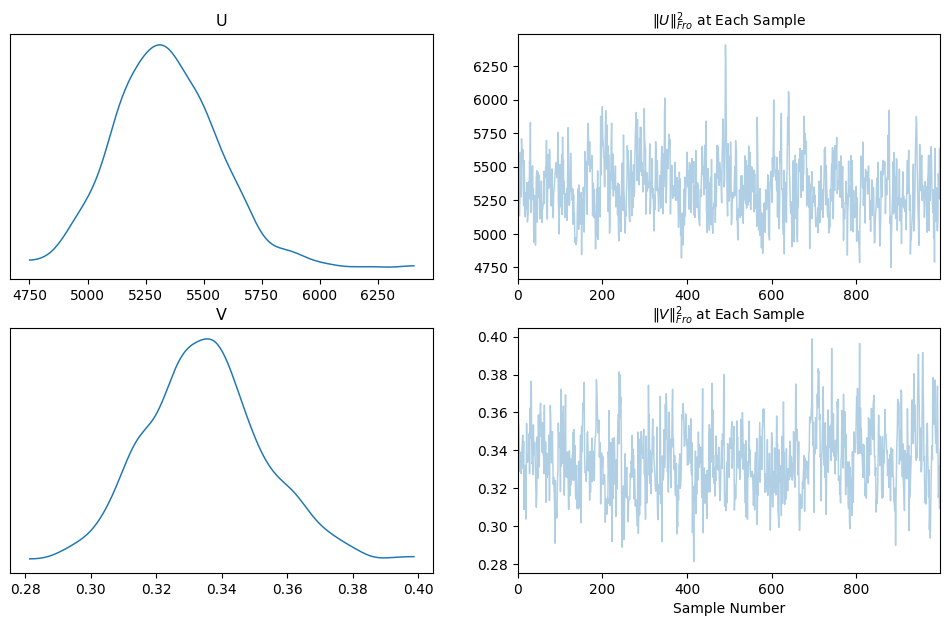

In [ ]:


# with gpu, log2(MIC), advi init, and 1000 tune samples, AND fixed correlations AND ESM PCA
hpmf_model.traceplot()

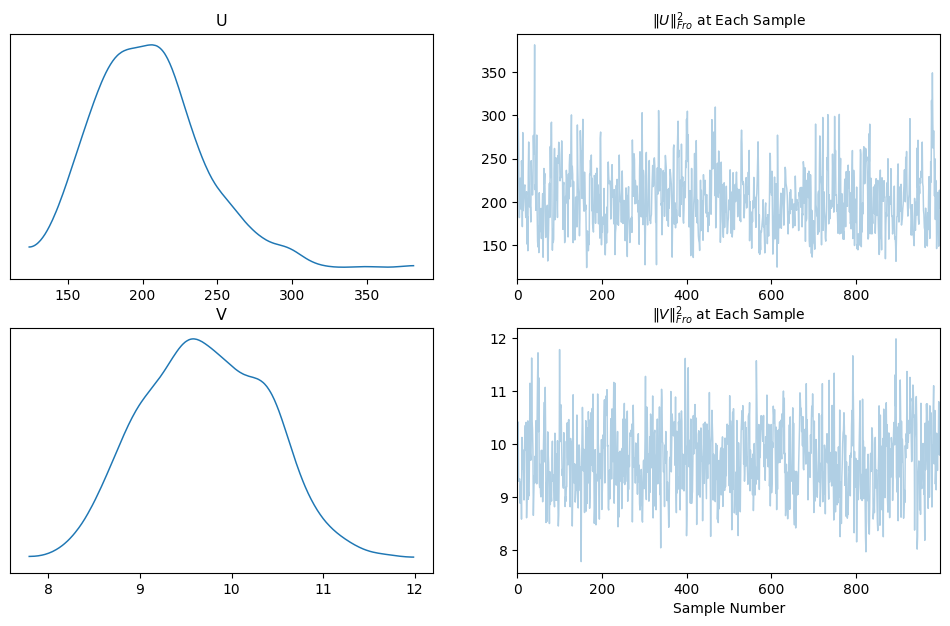

In [ ]:

# with gpu, log2(MIC), advi init, and 1000 tune samples, AND fixed correlations
hpmf_model.traceplot()

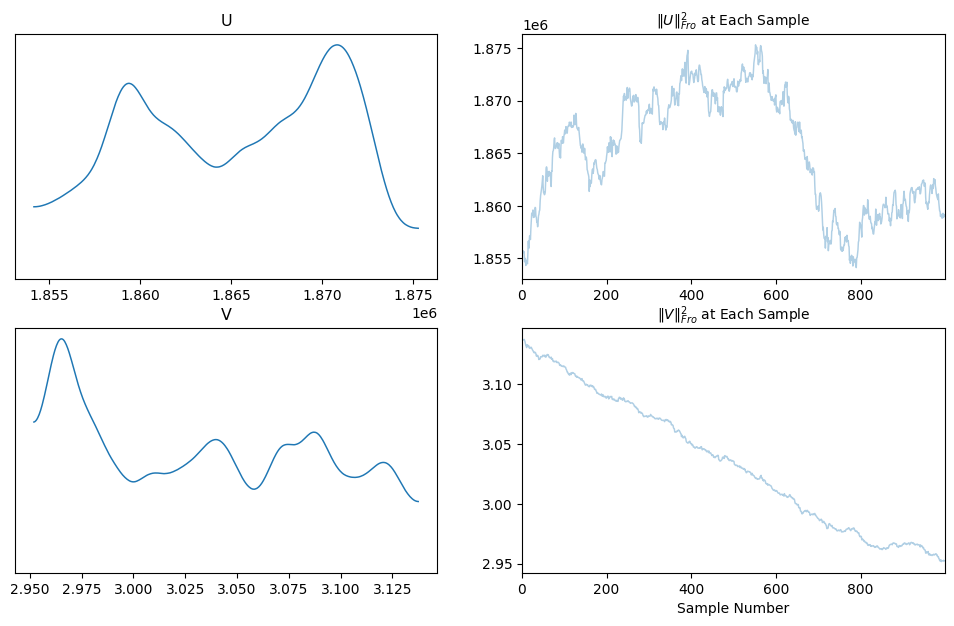

In [ ]:
# with gpu, log2(MIC), advi init, and 1000 tune samples
hpmf_model.traceplot()

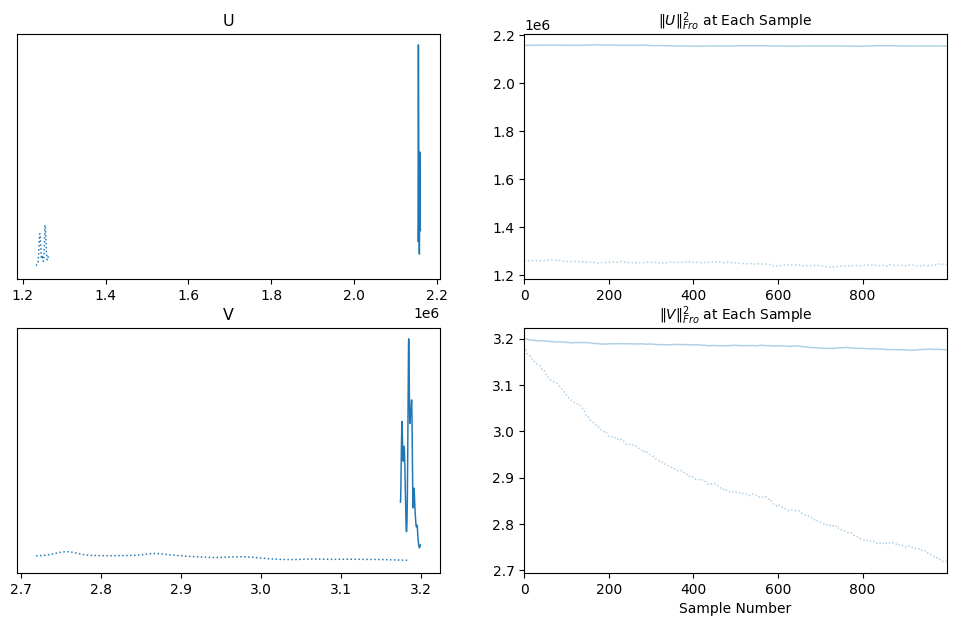

In [ ]:
hpmf_model.traceplot()

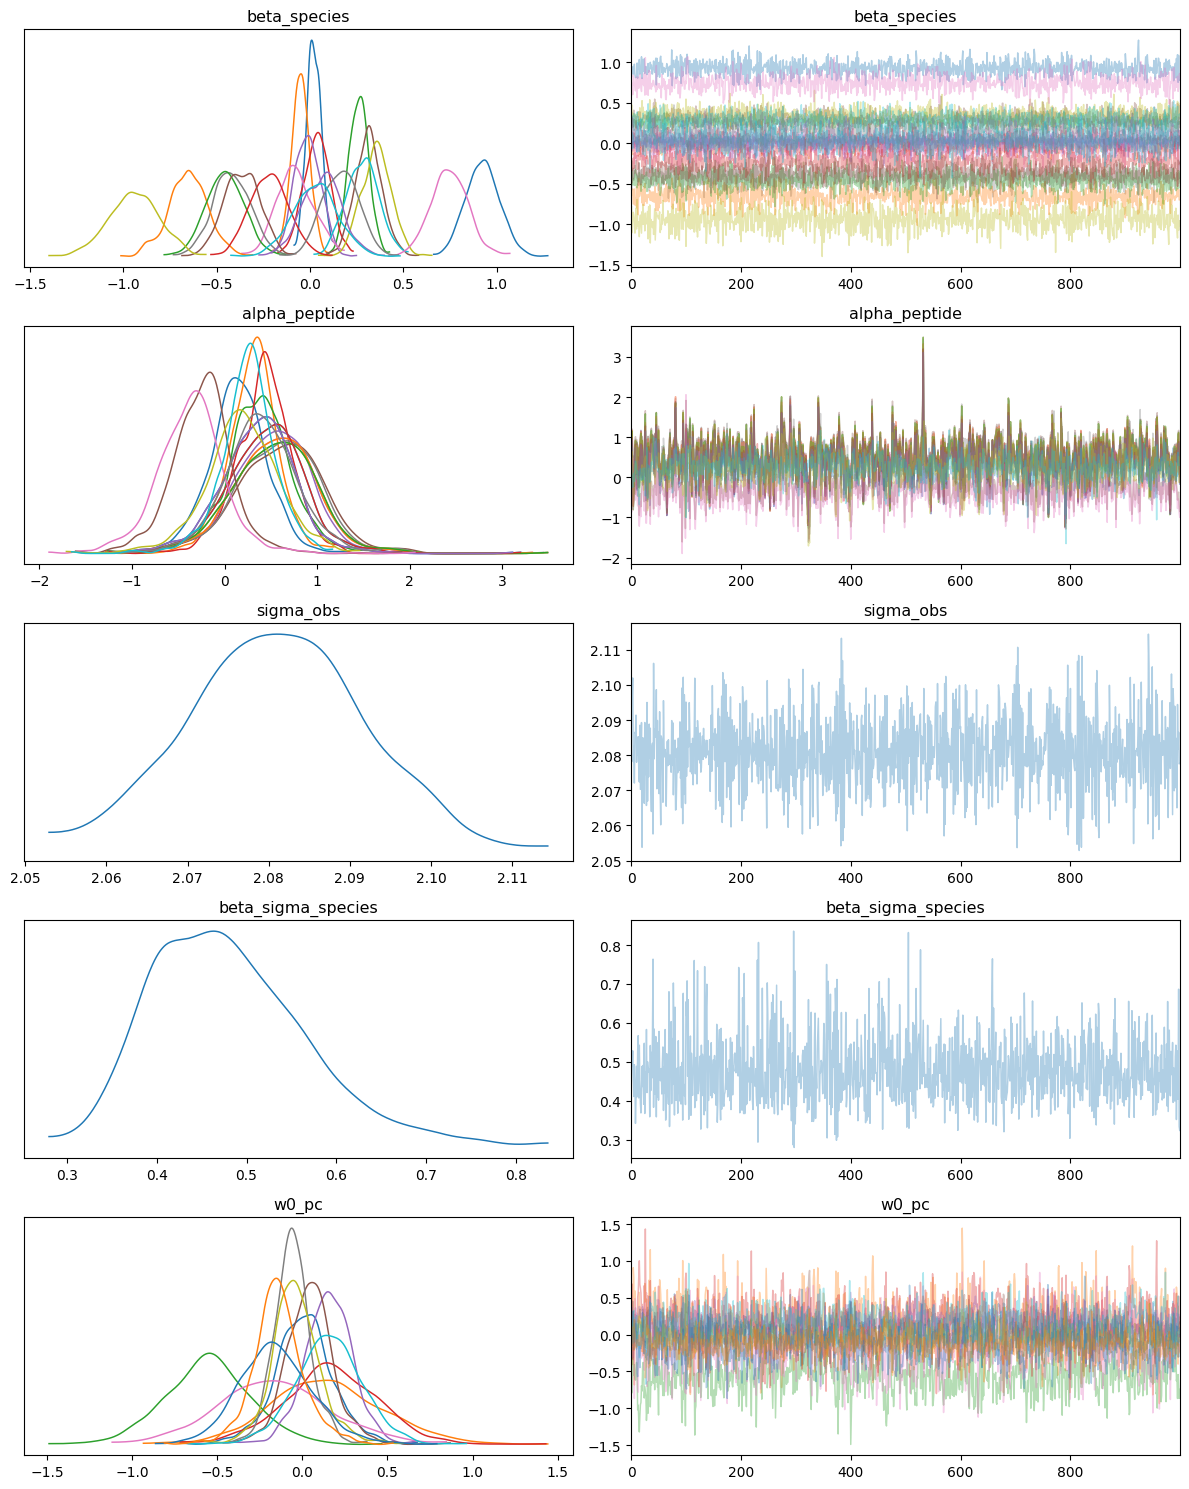

In [ ]:
idata = hpmf_model.idata
peptide_list=test_mic['Peptide ID'].unique()[:20]
species_list=top_species

# Always plot the global mean
var_names = []
coords = {}

if species_list is not None:
    var_names.append("beta_species")
    # Convert string names to the integer indices used in the model
    coords["species"] = [hpmf_model.species_dict[s] for s in species_list]

if peptide_list is not None:
    var_names.append("alpha_peptide")
    coords["peptide"] = [hpmf_model.peptide_dict[p] for p in peptide_list]

var_names.append("sigma_obs")
var_names.append("beta_sigma_species")
var_names.append("w0_pc")

# Plot using ArviZ
az.plot_trace(idata, var_names=var_names, coords=coords, figsize=(12, 3 * len(var_names)))
plt.tight_layout()
plt.show()

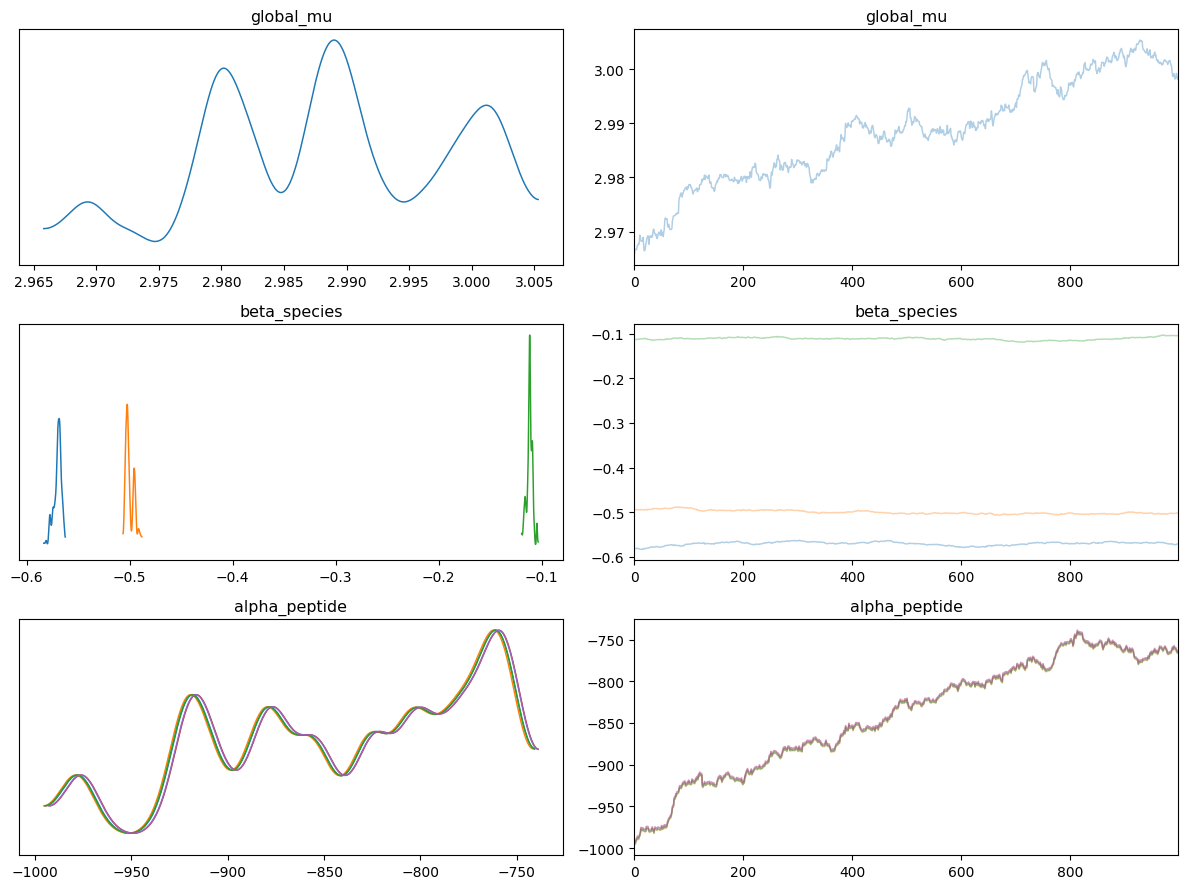

In [ ]:
# with gpu, log2(MIC), advi init, and 1000 tune samples

hpmf_model.plot_intercept_traces(
    species_list=top_species,
    peptide_list=test_mic['Peptide ID'].unique()[:5]
)

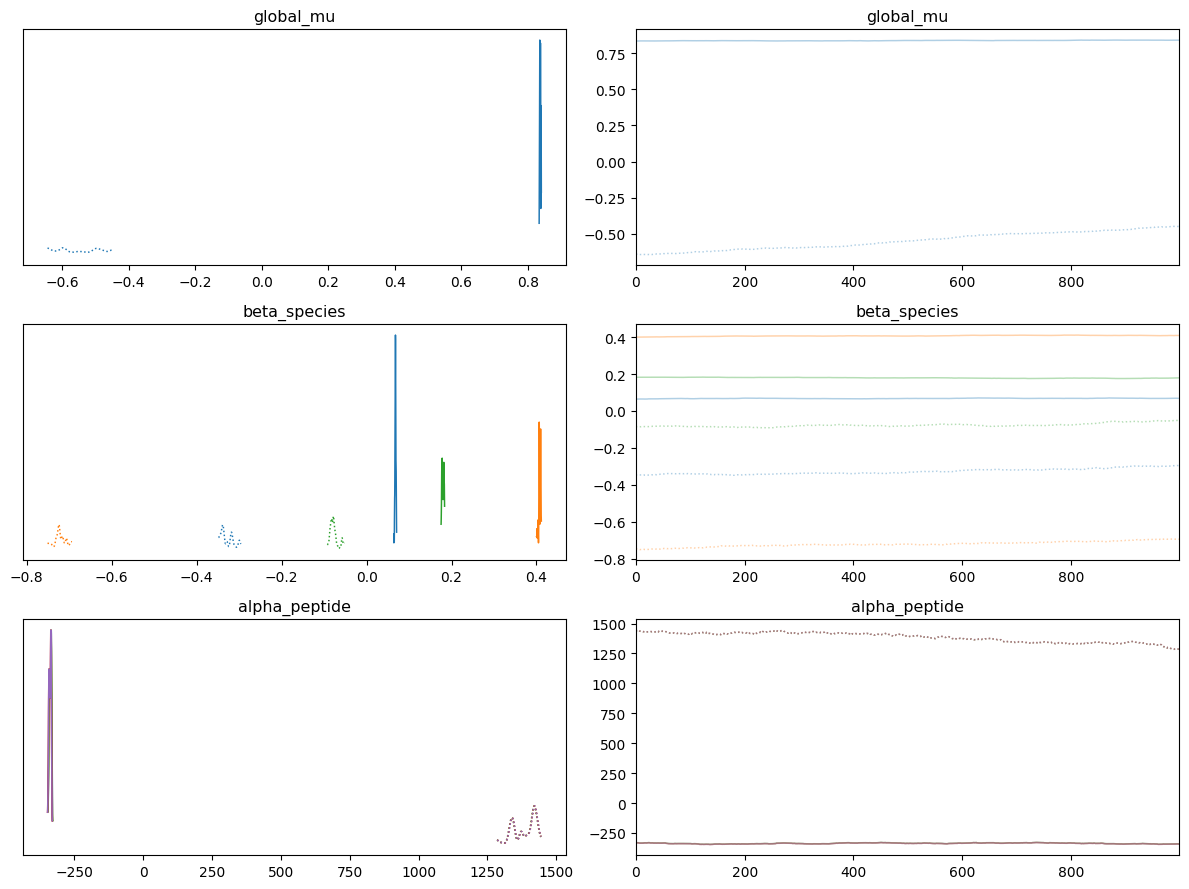

In [ ]:

hpmf_model.plot_intercept_traces(
    species_list=top_species,
    peptide_list=test_mic['Peptide ID'].unique()[:5]
)

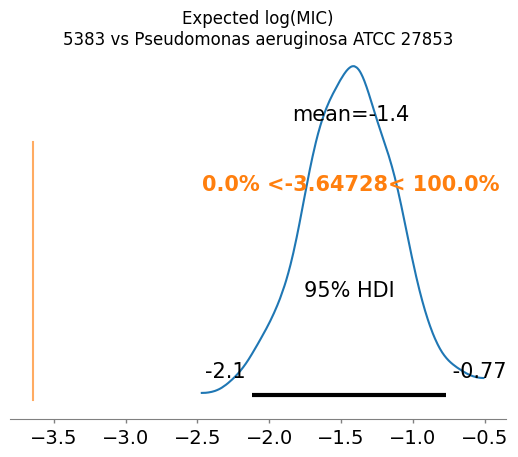

In [ ]:

idata = hpmf_model.idata
post = idata.posterior

true_mic = test_mic.iloc[1001]
peptide_id = true_mic['Peptide ID']
species_id = true_mic['Target Species']
true_mic = true_mic['mic']

# Look up the internal integer indices
try:
    p_idx = hpmf_model.peptide_dict[peptide_id]
    s_idx = hpmf_model.species_dict[species_id]
except KeyError as e:
    raise ValueError(f"ID {e} not found in the training dictionary.")

# 1. Extract the specific slices for this pair
alpha = post["alpha_peptide"].sel(peptide=p_idx)
beta = post["beta_species"].sel(species=s_idx)
u_vec = post["U"].sel(peptide=p_idx)
v_vec = post["V_species"].sel(species=s_idx)

# 2. Calculate the dot product across the latent factor dimension
# xarray automatically handles broadcasting across chains and draws
interaction = (u_vec * v_vec).sum(dim="latent_factor")

# 3. Reconstruct the expected log(MIC)
mu_posterior = alpha + beta + interaction # + post["global_mu"]

# 4. Plot using ArviZ
ax = az.plot_posterior(
    mu_posterior,
    ref_val=true_mic,
    point_estimate="mean",
    hdi_prob=0.95
)
ax.set_title(f"Expected log(MIC)\n{peptide_id} vs {species_id}")
plt.show()

In [ ]:
evaluate(hpmf_model, test_mic.iloc[:1000])

Output()


────────────────────────────────────────────────
  N        : 1000
  RMSE     : 1.8376
  Pearson  : r=0.6021  p=1.13e-99
  Spearman : r=0.6124  p=5.35e-104
────────────────────────────────────────────────



{'n': 1000,
 'rmse': np.float64(1.8376238256423676),
 'pearson_r': np.float64(0.6020883583530119),
 'pearson_p': np.float64(1.132210752315736e-99),
 'spearman_r': np.float64(0.6124439887416422),
 'spearman_p': np.float64(5.348320769771175e-104)}

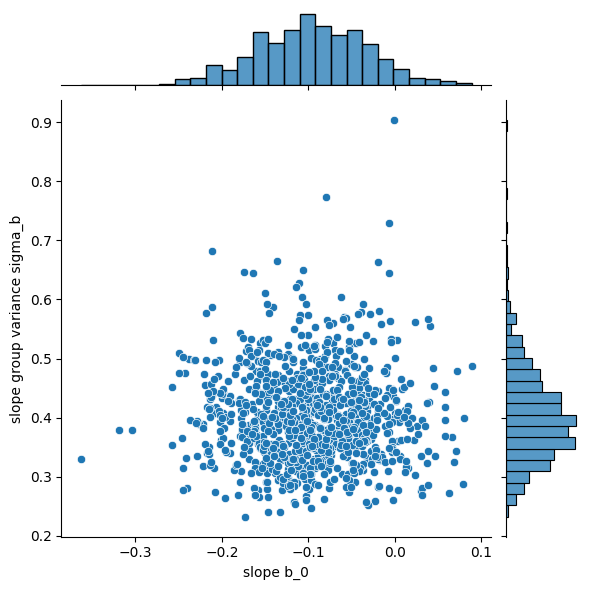

In [ ]:
# Diagnose problem with centered model?
import seaborn as sns

trace = hpmf_model.idata

x = pd.Series(trace['posterior']['beta_species'][0][:,0], name='slope b_0')
y = pd.Series(trace['posterior']['beta_sigma_species'][0], name='slope group variance sigma_b')

sns.jointplot(x=x, y=y);

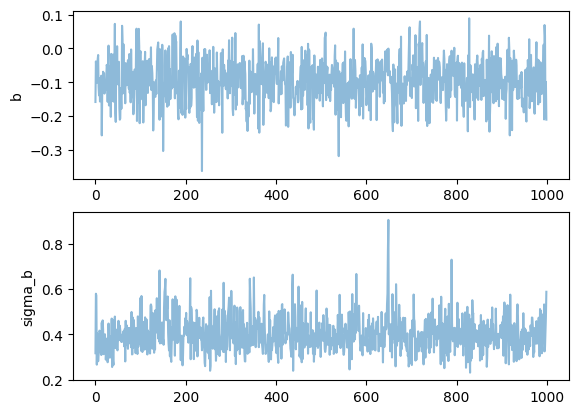

In [ ]:

fig, axs = plt.subplots(nrows=2)
axs[0].plot(trace['posterior']['beta_species'][0][:,0], alpha=.5);
axs[0].set(ylabel='b');
axs[1].plot(trace['posterior']['beta_sigma_species'][0], alpha=.5);
axs[1].set(ylabel='sigma_b');

In [ ]:
summary = az.summary(hpmf_model.idata, var_names=["alpha"], filter_vars="like")

summary

Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_peptide[0],-0.131,0.727,-1.533,1.137,0.100,0.038,52.0,147.0,NaN
alpha_peptide[1],1.227,0.611,0.139,2.307,0.083,0.046,57.0,120.0,NaN
alpha_peptide[2],1.491,0.631,0.360,2.614,0.084,0.039,58.0,169.0,NaN
alpha_peptide[3],1.735,0.582,0.595,2.707,0.070,0.033,69.0,161.0,NaN
alpha_peptide[4],0.151,0.482,-0.740,1.032,0.056,0.025,72.0,198.0,NaN
...,...,...,...,...,...,...,...,...,...
alpha_peptide[8298],-0.426,0.522,-1.357,0.536,0.069,0.050,57.0,152.0,NaN
alpha_peptide[8299],-0.562,0.575,-1.636,0.438,0.077,0.079,56.0,137.0,NaN
alpha_peptide[8300],-0.167,0.422,-0.890,0.687,0.051,0.028,69.0,106.0,NaN
alpha_peptide[8301],-0.637,1.028,-2.821,1.102,0.103,0.045,99.0,253.0,NaN


# CODE - DEV - replace in git

In [ ]:
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import os
import arviz as az
from sklearn.preprocessing import StandardScaler
import pandas as pd
import xarray as xr
import scipy.stats as stats
import pymc as pm
import pytensor.tensor as pt
import numpy as np
import logging


class Hybrid_PMF_dev:
    """Hybrid Probabilistic Matrix Factorization model for MIC prediction."""

    def __init__(self, obs_df, pc_df, esm_df, tax_df, dim=10,
                 horseshoe=True, include_esm=True, non_centered=False,
                 linreg=False, hierarchical=False, anchor_pc=False):
        """
        :param obs_df: DataFrame with ['Peptide ID', 'Target Species', 'mic']
                       (Uses LONG format)
        :param pc_df: pd.DataFrame shape (N_peptides, 12)
        :param esm_df: pd.DataFrame shape (N_peptides, 1280)
        :param tax_df: pd.DataFrame with ['strain', 'species', 'genus',...]
        :param dim: Latent factors (K)
        """
        self.name = "Hybrid_PMF"
        self.dim = dim

        # Clean Data
        strain_dict = {strain: idx for idx, strain in enumerate(obs_df['Target Species'].unique())}
        peptide_dict = {peptide: idx for idx, peptide in enumerate(obs_df['Peptide ID'].unique())}
        self.strain_dict = strain_dict
        self.peptide_dict = peptide_dict

        obs_df['strain_idx'] = obs_df['Target Species'].map(strain_dict)
        obs_df['peptide_idx'] = obs_df['Peptide ID'].map(peptide_dict)

        species_dict = {species: idx for idx, species in enumerate(tax_df['species'].unique())}
        genus_dict = {genus: idx for idx, genus in enumerate(tax_df['genus'].unique())}
        self.species_dict = species_dict
        self.genus_dict = genus_dict

        # Generate species_to_genus and strain_to_species from taxonomy_df
        # 1. Define all ranks in order (lowest to highest)
        ranks = ['strain', 'species', 'genus']

        # 2. Generate string-to-idx dictionaries for ALL ranks
        # We drop NaNs first so missing values aren't accidentally assigned an integer ID
        id_dicts = {'strain': strain_dict,
                    'species': species_dict,
                    'genus': genus_dict}
        # for rank in ranks:
        #     if rank in tax_df.columns:
        #         id_dicts[rank] = {name: idx for idx, name in enumerate(tax_df[rank].dropna().unique())}

        # # Extract them to explicit variables to match your naming convention
        # species_dict = id_dicts.get('species', {})
        # genus_dict = id_dicts.get('genus', {})
        # id_dicts['strain'] = strain_dict

        # 3. Create an index-only dataframe by replacing strings with their IDs
        tax_idx_df = tax_df.copy()
        for rank in ranks:
            if rank in tax_idx_df.columns and rank in id_dicts:
                # .map() is orders of magnitude faster than .replace()
                tax_idx_df[rank] = tax_idx_df[rank].map(id_dicts[rank])

        # 4. Generate the hierarchical mapping dictionaries (Child_ID -> Parent_ID)
        hierarchies = {}
        for i in range(len(ranks) - 1):
            child = ranks[i]
            parent = ranks[i+1]

            if child in tax_idx_df.columns and parent in tax_idx_df.columns:
                # Drop duplicates and NaNs to ensure a clean 1-to-1 or Many-to-1 mapping
                mapping = tax_idx_df[[child, parent]].dropna().drop_duplicates().astype(int)

                # Convert to dictionary: {child_idx: parent_idx}
                dict_name = f"{child}_to_{parent}_idx"
                hierarchies[dict_name] = mapping.set_index(child)[parent].to_dict()

        pc_df['original_idx'] = pc_df.index
        esm_df['original_idx'] = esm_df.index
        pc_df.index = pc_df.index.map(peptide_dict)
        esm_df.index = esm_df.index.map(peptide_dict)
        self.pc_df = pc_df
        self.esm_df = esm_df

        # Extract Data
        obs_peptide_idx = obs_df['peptide_idx'].values
        obs_strain_idx = obs_df['strain_idx'].values
        obs_mic = obs_df['mic'].values
        # Get the unique integer indices (0 to n_peptides-1) in order
        unique_pep_idx = np.sort(np.unique(obs_peptide_idx))

        # Slice the dataframes using the unique indices
        # And drop the original_idx column
        pc_input = pc_df.loc[unique_pep_idx].iloc[:, :-1].values
        esm_input = esm_df.loc[unique_pep_idx].iloc[:, :-1].values

        n_peptides = len(np.unique(obs_peptide_idx))
        n_strains = len(np.unique(obs_strain_idx))
        n_species = len(species_dict)
        n_genera = len(genus_dict)
        n_obs = len(obs_mic)

        # Create an array of length n_species
        species_to_genus_idx = np.zeros(n_species, dtype=int)
        for child_idx, parent_idx in hierarchies['species_to_genus_idx'].items():
            species_to_genus_idx[child_idx] = parent_idx

        # Create an array of length n_strains
        strain_to_species_idx = np.zeros(n_strains, dtype=int)
        for child_idx, parent_idx in hierarchies['strain_to_species_idx'].items():
            strain_to_species_idx[child_idx] = parent_idx

        self.idata = None
        self.idata_vi = None

        logging.info("Building the PMF model...")

        with pm.Model(
                coords={
                    "peptide": range(n_peptides),
                    "strain": range(n_strains),
                    "species": range(n_species),
                    "genus": range(n_genera),
                    "latent_factor": range(dim),
                    "obs_id": range(n_obs),
                    "phys_chem": range(pc_input.shape[1]),
                    "esm": range(esm_input.shape[1])
                }
        ) as pmf:
            # --- DATA CONTAINERS ---
            pep_idx_ = pm.Data("pep_idx", obs_peptide_idx, dims="obs_id")
            strain_idx_ = pm.Data("strain_idx", obs_strain_idx, dims="obs_id")
            spec_idx_ = pm.Data("spec_idx", strain_to_species_idx, dims="strain")
            genus_idx_ = pm.Data("genus_idx", species_to_genus_idx, dims="species")
            mic_ = pm.Data("mic", obs_mic, dims="obs_id").astype(np.float32)

            X_pc = pm.Data("X_pc", pc_input, dims=("peptide", "phys_chem")).astype(np.float32)
            X_esm = pm.Data("X_esm", esm_input, dims=("peptide", "esm")).astype(np.float32)

            if not linreg:

                # --- HYBRID PEPTIDE MAPPING (u_i) ---
                # 1. Physical Features (Standard Weakly Informative Prior)
                # 1. Sample the unconstrained bulk of the weights
                B_pc = pm.Normal("B_pc", mu=0, sigma=1, dims=("phys_chem", "latent_factor"))

                if anchor_pc and dim <= 12:
                    # 2. Sample K positive anchors
                    B_pc_anchors = pm.HalfNormal("B_pc_anchors", sigma=1, shape=dim)

                    # 3. Stitch them together using PyTensor
                    # This replaces the diagonal of the top KxK block of B_pc with strictly positive values.
                    B_pc = pt.set_subtensor(
                        B_pc[np.arange(dim), np.arange(dim)],
                        B_pc_anchors
                    )

                if include_esm:
                    if horseshoe:
                        # 2. ESM Features (COLUMN-WISE HORSESHOE PRIOR - Non-Centered)
                        # Global shrinkage
                        tau_esm = pm.HalfCauchy("tau_esm", beta=1)
                        # Local shrinkage (One per ESM feature, applied across all K dims)
                        lambda_esm = pm.HalfCauchy("lambda_esm", beta=1, dims="esm")
                        # Raw weights
                        B_esm_raw = pm.Normal("B_esm_raw", mu=0, sigma=1, dims=("esm", "latent_factor"))
                        # Decoupled matrix multiplication
                        B_esm = pm.Deterministic(
                            "B_esm",
                            B_esm_raw * (tau_esm * lambda_esm)[:, None],
                            dims=("esm", "latent_factor")
                        )
                    else:
                        B_esm = pm.Normal("B_esm", mu=0, sigma=1, dims=("esm", "latent_factor"))

                    # 3. Calculate Latent Peptides (U) via Matrix Dot Product
                    # U is shape (N_peptides, K)
                    U = pm.Deterministic("U", pt.dot(X_pc, B_pc) + pt.dot(X_esm, B_esm), dims=("peptide", "latent_factor"))
                else:
                    U = pm.Deterministic("U", pt.dot(X_pc, B_pc), dims=("peptide", "latent_factor"))

                # --- TAXONOMIC HIERARCHY (v_j) ---
                # sigma_species = pm.HalfNormal("sigma_species",
                #                               sigma=1) #, dims=("latent_factor")) # shape D or 1?
                if hierarchical:
                    V_genus = pm.Normal("V_genus", mu=0, sigma=1, dims=("genus", "latent_factor"))   # Make ZeroSumNormal?
                    if non_centered:
                        V_species_raw = pm.Normal("V_species_raw", mu=0,
                                            sigma=1, dims=("species", "latent_factor"))
                        V_species = pm.Deterministic("V_species", V_genus[genus_idx_] + V_species_raw,
                                             dims=("species", "latent_factor"))
                    else:
                        V_species = pm.Normal("V_species", mu=V_genus[genus_idx_],
                                            sigma=1, dims=("species", "latent_factor"))
                    V_mu = V_species[spec_idx_]
                else:
                    V_mu = 0

                #### hard coded sigma to avoid correlation with learned variance in U ####
                if non_centered:
                    V_strains_raw = pm.Normal("V_strains_raw", mu=0,
                                        sigma=1, dims=("strain", "latent_factor"))
                    V_strains = pm.Deterministic("V_strains", V_mu + V_strains_raw,
                                         dims=("strain", "latent_factor"))
                else:
                    V_strains = pm.Normal("V_strains", mu=V_mu,
                                        sigma=1, dims=("strain", "latent_factor"))

            # --- INTERCEPTS ---
            ## global_mu removed to avoid centering issue (where sampler can add to mu and subtract elsewhere)
            ## required that I subtract the mean from the dataset before inputting

            # Strain Intercept (Hierarchical Intrinsic Resistance)
            beta_strain_sigma = pm.HalfNormal("beta_strain_sigma", sigma=1)

            if hierarchical:
                beta_genus = pm.ZeroSumNormal("beta_genus", sigma=1, dims="genus")
                if non_centered:
                    beta_species_raw = pm.Normal("beta_species_raw", mu=0,
                                     sigma=1, dims="species")
                    beta_species = pm.Deterministic("beta_species", beta_genus[genus_idx_] + beta_species_raw, dims="species")
                else:
                    beta_species = pm.Normal("beta_species", mu=beta_genus[genus_idx_],
                                              sigma=1, dims="species")
                beta_mu = beta_species[spec_idx_]
            else:
                beta_mu = 0

            if non_centered:
                # 1. Sample raw from a standard normal
                beta_strain_raw = pm.Normal("beta_strain_raw", mu=0, sigma=1, dims="strain")
                # 2. Scale it deterministically
                beta_strain = pm.Deterministic("beta_strain", beta_mu + beta_strain_raw * beta_strain_sigma, dims="strain")
            elif hierarchical:
                beta_strain = pm.Normal("beta_strain", mu=beta_mu,
                                        dims="strain", sigma=beta_strain_sigma)
            else:
                beta_strain = pm.ZeroSumNormal("beta_strain",
                                        dims="strain", sigma=beta_strain_sigma)


            # Peptide Intercept (Cold-start friendly mapping)
            w0_pc = pm.Normal("w0_pc", mu=0, sigma=1, dims="phys_chem")

            if include_esm:
                w0_esm = pm.Normal("w0_esm", mu=0, sigma=0.1, dims="esm")
                alpha_peptide = pm.Deterministic("alpha_peptide", pt.dot(X_pc, w0_pc) + pt.dot(X_esm, w0_esm),
                                                dims="peptide")
            else:
                alpha_peptide = pm.Deterministic("alpha_peptide", pt.dot(X_pc, w0_pc),
                                                dims="peptide")

            # --- LIKELIHOOD ---
            if not linreg:
                # 1. Gather the relevant parameters for the observed data points
                U_obs = U[pep_idx_]  # Shape (N_obs, K)
                V_obs = V_strains[strain_idx_]  # Shape (N_obs, K)

                # 2. Calculate interaction term using batched dot product along the K dimension
                interaction = pt.batched_dot(U_obs, V_obs)
            else:
                # Use pep_idx_.shape[0] to get the size of the tensor
                interaction = pt.zeros(pep_idx_.shape[0])

            # 3. Build the predicted mean
            mu_obs = alpha_peptide[pep_idx_] + beta_strain[strain_idx_] + interaction #+ global_mu

            # 4. Observation Noise
            sigma_obs = pm.HalfNormal("sigma_obs", sigma=1)

            # 5. Final Distribution (assuming output is not in log space yet)
            pm.Normal("MIC_obs", mu=mu_obs, sigma=sigma_obs, observed=mic_, dims="obs_id")

        self.model = pmf
        logging.info("Done building the PMF model.")

    # Draw MCMC samples.
    def draw_samples(self, **kwargs):
        with self.model:
            if 'chains' in kwargs and kwargs['chains'] > 1 and \
                'nuts_sampler' in kwargs and kwargs['nuts_sampler'] == 'numpyro':
                    self.idata = sample_numpyro_nuts(
                                  **kwargs,
                                  chain_method="vectorized", # Guaranteed to use vmap
                                  keep_untransformed=False
                              )
            else:
                self.idata = pm.sample(**kwargs)
        return self.idata

    def var_inference(self, **kwargs):
        with self.model:
            self.idata_vi = pm.fit(**kwargs)
        return self.idata_vi

    def predict_new_peptides(self, new_long_df, return_full_posterior=False):
        # 1. Identify the unique peptides in this specific prediction batch
        predict_peps = new_long_df["Peptide ID"].unique()

        # 2. Extract their features from your master dataframes
        # Assumes original_idx is a column containing the Peptide IDs
        pc_df_predict = self.pc_df[self.pc_df['original_idx'].isin(predict_peps)]
        esm_df_predict = self.esm_df[self.esm_df['original_idx'].isin(predict_peps)]

        # 3. Create a LOCAL dictionary mapping to 0, 1, 2... N
        # This prevents the PyMC IndexError trap
        local_pep_dict = {pep: i for i, pep in enumerate(predict_peps)}

        # 4. Map the observation dataframe to these local indices
        obs_peptide_idx = new_long_df["Peptide ID"].map(local_pep_dict).values

        # 5. Extract feature matrices in the exact order of the local dictionary
        # Make sure to set the index to Peptide ID temporarily so .loc alignment works perfectly
        pc_input = pc_df_predict.set_index('original_idx').loc[predict_peps]
        esm_input = esm_df_predict.set_index('original_idx').loc[predict_peps]

        # Ensure all target species exist in the training dictionary
        assert len(set(new_long_df["Target Species"]) - set(self.strain_dict.keys())) == 0, \
            "Cannot predict for a species not in the training set!"
        with self.model:
            pm.set_data(
                {
                    "pep_idx":  obs_peptide_idx,
                    "strain_idx": new_long_df["Target Species"].map(self.strain_dict).values,
                    "mic":      np.ones(len(new_long_df)), # Dummy values for shape
                    "X_pc":     pc_input.values,
                    "X_esm":    esm_input.values,
                },
                coords={
                    "obs_id":  range(len(new_long_df)),
                    "peptide": range(len(predict_peps)),
                },
            )

            idata = self.idata if hasattr(self, 'idata') and self.idata else self.idata_vi
            ppc = pm.sample_posterior_predictive(idata, extend_inferencedata=False)

        raw = ppc.posterior_predictive["MIC_obs"]
        return raw if return_full_posterior else raw.mean(("chain", "draw")).values

    def evaluate(self, test_df, label=""):
        # check for MCMC first
        y_pred = self.predict_new_peptides(test_df)
        y_true = test_df["mic"].values
        return compute_metrics(y_true, y_pred, label=label)

    def _norms(self):
        """Return norms of latent variables at each step in the
        sample trace. These can be used to monitor convergence
        of the sampler.
        """
        # check for MCMC first
        idata = self.idata if self.idata else self.idata_vi
        norms = dict()
        norms["U"] = xr.apply_ufunc(
            np.linalg.norm,
            idata.posterior["U"],
            input_core_dims=[["peptide", "latent_factor"]],
            kwargs={"ord": "fro", "axis": (-2, -1)},
        )
        norms["V"] = xr.apply_ufunc(
            np.linalg.norm,
            idata.posterior["V_strains"],
            input_core_dims=[["strain", "latent_factor"]],
            kwargs={"ord": "fro", "axis": (-2, -1)},
        )
        return xr.Dataset(norms)

    def traceplot(self):
        """Plot Frobenius norms of U and V as a function of sample #."""
        fig, axs = plt.subplots(2, 2, figsize=(12, 7))
        az.plot_trace(self._norms(), axes=axs)
        axs[0][1].set_title(label=r"$\|U\|_{Fro}^2$ at Each Sample", fontsize=10)
        axs[1][1].set_title(label=r"$\|V\|_{Fro}^2$ at Each Sample", fontsize=10)
        axs[1][1].set_xlabel("Sample Number", fontsize=10)

    def plot_intercept_traces(self, species_list=None, peptide_list=None, **kwargs):
        """
        Plot the traces for the global mean and specific intercepts.

        :param species_list: List of string 'Target Species' to plot.
        :param peptide_list: List of string 'Peptide ID' to plot.
        """
        idata = self.idata if hasattr(self, 'idata') and self.idata else self.idata_vi

        # Always plot the global mean
        var_names = [] #["global_mu"]
        coords = {}

        if species_list is not None:
            var_names.append("beta_species")
            # Convert string names to the integer indices used in the model
            coords["species"] = [self.strain_dict[s] for s in species_list]

        if peptide_list is not None:
            var_names.append("alpha_peptide")
            coords["peptide"] = [self.peptide_dict[p] for p in peptide_list]

        var_names.append("sigma_obs")
        var_names.append("beta_sigma_species")

        # Plot using ArviZ
        az.plot_trace(idata, var_names=var_names, coords=coords, figsize=(12, 3 * len(var_names)), **kwargs)
        plt.tight_layout()

    def plot_mic_posterior(self, peptide_id, strains_id, true_mic=None, **kwargs):
        """
        Reconstruct and plot the posterior distribution of the expected log(MIC)
        for a specific peptide and strain.

        :param peptide_id: String ID of the peptide.
        :param strains_id: String ID of the target strain.
        :param true_mic: Optional float (in log space) to plot as a reference line.
        """
        idata = self.idata if hasattr(self, 'idata') and self.idata else self.idata_vi
        post = idata.posterior

        # Look up the internal integer indices
        try:
            p_idx = self.peptide_dict[peptide_id]
            s_idx = self.strain_dict[strains_id]
        except KeyError as e:
            raise ValueError(f"ID {e} not found in the training dictionary.")

        # 1. Extract the specific slices for this pair
        alpha = post["alpha_peptide"].sel(peptide=p_idx)
        beta = post["beta_strain"].sel(strain=s_idx)
        u_vec = post["U"].sel(peptide=p_idx)
        v_vec = post["V_strains"].sel(strain=s_idx)

        # 2. Calculate the dot product across the latent factor dimension
        # xarray automatically handles broadcasting across chains and draws
        interaction = (u_vec * v_vec).sum(dim="latent_factor")

        # 3. Reconstruct the expected log(MIC)
        mu_posterior = alpha + beta + interaction # + post["global_mu"]

        # 4. Plot using ArviZ
        ax = az.plot_posterior(
            mu_posterior,
            ref_val=true_mic,
            point_estimate="mean",
            hdi_prob=0.95,
            **kwargs
        )
        ax.set_title(f"Expected log(MIC)\n{peptide_id} vs {strains_id}")

        # Return the raw xarray DataArray in case you want to do math with it later
        return mu_posterior, ax

    def plot_feature_weights(self, **kwargs):
        """Plot a forest plot of the physical feature weights (w0_pc)."""
        idata = self.idata if hasattr(self, 'idata') and self.idata else self.idata_vi

        # Get the original column names from your dataframe
        feature_names = self.pc_df.columns[:12].tolist()

        # Create the forest plot
        axes = az.plot_forest(
            idata,
            var_names=["w0_pc"],
            combined=True,
            hdi_prob=0.95,
            figsize=(8, 6),
            **kwargs
        )

        # Relabel the y-axis with the actual feature names
        axes[0].set_yticklabels(feature_names[::-1]) # Reversed because ArviZ plots bottom-to-top
        axes[0].set_title("Posterior Weights of Physical Features (95% HDI)")
        plt.axvline(0, color='red', linestyle='--', alpha=0.5)

        return axes

In [ ]:

import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import os
import arviz as az
from sklearn.preprocessing import StandardScaler
import pandas as pd
import xarray as xr
import scipy.stats as stats
import pymc as pm
import pytensor.tensor as pt
import numpy as np
import logging


class Residual_Hybrid_PMF_dev:
    """Hybrid Probabilistic Matrix Factorization model for MIC prediction."""

    def __init__(self, obs_df, pc_df, esm_df, tax_df, dim=10,
                 horseshoe=True, include_esm=True, non_centered=False,
                 linreg=False, hierarchical=False, anchor_pc=False):
        """
        :param obs_df: DataFrame with ['Peptide ID', 'Target Species', 'mic']
                       (Uses LONG format)
        :param pc_df: pd.DataFrame shape (N_peptides, 12)
        :param esm_df: pd.DataFrame shape (N_peptides, 1280)
        :param tax_df: pd.DataFrame with ['strain', 'species', 'genus',...]
        :param dim: Latent factors (K)
        """
        self.name = "Hybrid_PMF"
        self.dim = dim

        # Clean Data
        strain_dict = {strain: idx for idx, strain in enumerate(obs_df['Target Species'].unique())}
        peptide_dict = {peptide: idx for idx, peptide in enumerate(obs_df['Peptide ID'].unique())}
        self.strain_dict = strain_dict
        self.peptide_dict = peptide_dict

        obs_df['strain_idx'] = obs_df['Target Species'].map(strain_dict)
        obs_df['peptide_idx'] = obs_df['Peptide ID'].map(peptide_dict)

        pc_df['original_idx'] = pc_df.index
        esm_df['original_idx'] = esm_df.index
        pc_df.index = pc_df.index.map(peptide_dict)
        esm_df.index = esm_df.index.map(peptide_dict)
        self.pc_df = pc_df
        self.esm_df = esm_df

        # Extract Data
        obs_peptide_idx = obs_df['peptide_idx'].values
        obs_strain_idx = obs_df['strain_idx'].values
        obs_mic = obs_df['mic'].values
        # Get the unique integer indices (0 to n_peptides-1) in order
        unique_pep_idx = np.sort(np.unique(obs_peptide_idx))

        # Slice the dataframes using the unique indices
        # And drop the original_idx column
        pc_input = pc_df.loc[unique_pep_idx].iloc[:, :-1].values
        esm_input = esm_df.loc[unique_pep_idx].iloc[:, :-1].values

        n_peptides = len(np.unique(obs_peptide_idx))
        n_strains = len(np.unique(obs_strain_idx))
        n_obs = len(obs_mic)

        self.idata = None
        self.idata_vi = None

        logging.info("Building the PMF model...")

        with pm.Model(
                coords={
                    "peptide": range(n_peptides),
                    "strain": range(n_strains),
                    "latent_factor": range(dim),
                    "obs_id": range(n_obs),
                    "phys_chem": range(pc_input.shape[1]),
                    "esm": range(esm_input.shape[1])
                }
        ) as pmf:
            # --- DATA CONTAINERS ---
            pep_idx_ = pm.Data("pep_idx", obs_peptide_idx, dims="obs_id")
            strain_idx_ = pm.Data("strain_idx", obs_strain_idx, dims="obs_id")
            mic_ = pm.Data("mic", obs_mic, dims="obs_id").astype(np.float32)

            X_pc = pm.Data("X_pc", pc_input, dims=("peptide", "phys_chem")).astype(np.float32)
            X_esm = pm.Data("X_esm", esm_input, dims=("peptide", "esm")).astype(np.float32)

            if not linreg:

                # --- HYBRID PEPTIDE MAPPING (u_i) ---
                # 1. Physical Features (Standard Weakly Informative Prior)
                # 1. Sample the unconstrained bulk of the weights
                B_pc = pm.Normal("B_pc", mu=0, sigma=1, dims=("phys_chem", "latent_factor"))

                if anchor_pc and dim <= 12:
                    # 2. Sample K positive anchors
                    B_pc_anchors = pm.HalfNormal("B_pc_anchors", sigma=1, shape=dim)

                    # 3. Stitch them together using PyTensor
                    # This replaces the diagonal of the top KxK block of B_pc with strictly positive values.
                    B_pc = pt.set_subtensor(
                        B_pc[np.arange(dim), np.arange(dim)],
                        B_pc_anchors
                    )



            # --- INTERCEPTS ---
            ## global_mu removed to avoid centering issue (where sampler can add to mu and subtract elsewhere)
            ## required that I subtract the mean from the dataset before inputting

            # Strain Intercept (Hierarchical Intrinsic Resistance)
            beta_strain_sigma = pm.HalfNormal("beta_strain_sigma", sigma=1)

            beta_strain = pm.ZeroSumNormal("beta_strain",
                                        dims="strain", sigma=beta_strain_sigma)


            # Peptide Intercept (Cold-start friendly mapping)
            w0_pc = pm.Normal("w0_pc", mu=0, sigma=1, dims="phys_chem")

            if include_esm:
                w0_esm = pm.Normal("w0_esm", mu=0, sigma=0.1, dims="esm")
                alpha_peptide = pm.Deterministic("alpha_peptide", pt.dot(X_pc, w0_pc) + pt.dot(X_esm, w0_esm),
                                                dims="peptide")
            else:
                alpha_peptide = pm.Deterministic("alpha_peptide", pt.dot(X_pc, w0_pc),
                                                dims="peptide")

            # --- LIKELIHOOD ---
            if not linreg:
                # 1. Gather the relevant parameters for the observed data points
                sigma_u = pm.HalfNormal("sigma_u", 1.0)
                sigma_v = pm.HalfNormal("sigma_v", 1.0)

                U = pm.Normal(
                    "U",
                    mu=0,
                    sigma=sigma_u,
                    dims=("peptide", "latent_factor")
                )

                V = pm.Normal(
                    "V",
                    mu=0,
                    sigma=sigma_v,
                    dims=("strain", "latent_factor")
                )

                U_obs = U[pep_idx_]
                V_obs = V[strain_idx_]

                # 2. Calculate interaction term using batched dot product along the K dimension
                interaction = pt.batched_dot(U_obs, V_obs)
            else:
                # Use pep_idx_.shape[0] to get the size of the tensor
                interaction = pt.zeros(pep_idx_.shape[0])

            # 3. Build the predicted mean
            mu_obs = (
                  alpha_peptide[pep_idx_]
                  + beta_strain[strain_idx_]
                  + interaction
              )

            # 4. Observation Noise
            sigma_obs = pm.HalfNormal("sigma_obs", sigma=1)

            # 5. Final Distribution (assuming output is not in log space yet)
            pm.Normal("MIC_obs", mu=mu_obs, sigma=sigma_obs, observed=mic_, dims="obs_id")

        self.model = pmf
        logging.info("Done building the PMF model.")

    # Draw MCMC samples.
    def draw_samples(self, **kwargs):
        with self.model:
            if 'chains' in kwargs and kwargs['chains'] > 1 and \
                'nuts_sampler' in kwargs and kwargs['nuts_sampler'] == 'numpyro':
                    self.idata = sample_numpyro_nuts(
                                  **kwargs,
                                  chain_method="vectorized", # Guaranteed to use vmap
                                  keep_untransformed=False
                              )
            else:
                self.idata = pm.sample(**kwargs)
        return self.idata

    def var_inference(self, **kwargs):
        with self.model:
            self.idata_vi = pm.fit(**kwargs)
        return self.idata_vi

    def predict_new_peptides(self, new_long_df, return_full_posterior=False):
        # 1. Identify the unique peptides in this specific prediction batch
        predict_peps = new_long_df["Peptide ID"].unique()

        # 2. Extract their features from your master dataframes
        # Assumes original_idx is a column containing the Peptide IDs
        pc_df_predict = self.pc_df[self.pc_df['original_idx'].isin(predict_peps)]
        esm_df_predict = self.esm_df[self.esm_df['original_idx'].isin(predict_peps)]

        # 3. Create a LOCAL dictionary mapping to 0, 1, 2... N
        # This prevents the PyMC IndexError trap
        local_pep_dict = {pep: i for i, pep in enumerate(predict_peps)}

        # 4. Map the observation dataframe to these local indices
        obs_peptide_idx = new_long_df["Peptide ID"].map(local_pep_dict).values

        # 5. Extract feature matrices in the exact order of the local dictionary
        # Make sure to set the index to Peptide ID temporarily so .loc alignment works perfectly
        pc_input = pc_df_predict.set_index('original_idx').loc[predict_peps]
        esm_input = esm_df_predict.set_index('original_idx').loc[predict_peps]

        # Ensure all target species exist in the training dictionary
        assert len(set(new_long_df["Target Species"]) - set(self.strain_dict.keys())) == 0, \
            "Cannot predict for a species not in the training set!"


        post = self.idata.posterior

        obs_strain_idx = new_long_df["Target Species"].map(self.strain_dict).values

        X_pc_new = xr.DataArray(pc_input.values, dims=("peptide_new", "phys_chem"))

        alpha_new = xr.dot(X_pc_new, post["w0_pc"], dims="phys_chem")

        #get features
        obs_strain_idx = new_long_df["Target Species"].map(self.strain_dict).values

        X_esm_new = xr.DataArray(esm_input.values, dims=("peptide_new", "esm"))
        alpha_new = alpha_new + xr.dot(X_esm_new, post["w0_esm"], dims="esm")

        #new alpha from calculation and beta from sample
        alpha_obs = alpha_new.isel(peptide_new=obs_peptide_idx).rename({"peptide_new": "obs_id"})
        beta_obs = post["beta_strain"].isel(strain=obs_strain_idx).rename({"strain": "obs_id"})

        #mean u, post v
        u_mean = post["U"].mean(dim="peptide")
        v_obs = post["V"].isel(strain=obs_strain_idx).rename({"strain": "obs_id"})

        interaction = (u_mean * v_obs).sum(dim="latent_factor")

        mu = alpha_obs + beta_obs + interaction

        #take mean of chain samples
        return mu.mean(dim=("chain", "draw")).values



    def evaluate(self, test_df, label=""):
        # check for MCMC first
        y_pred = self.predict_new_peptides(test_df)
        y_true = test_df["mic"].values
        return compute_metrics(y_true, y_pred, label=label)

    def _norms(self):
        """Return norms of latent variables at each step in the
        sample trace. These can be used to monitor convergence
        of the sampler.
        """
        # check for MCMC first
        idata = self.idata if self.idata else self.idata_vi
        norms = dict()
        norms["U"] = xr.apply_ufunc(
            np.linalg.norm,
            idata.posterior["U"],
            input_core_dims=[["peptide", "latent_factor"]],
            kwargs={"ord": "fro", "axis": (-2, -1)},
        )
        norms["V"] = xr.apply_ufunc(
            np.linalg.norm,
            idata.posterior["V"],
            input_core_dims=[["strain", "latent_factor"]],
            kwargs={"ord": "fro", "axis": (-2, -1)},
        )
        return xr.Dataset(norms)

    def traceplot(self):
        """Plot Frobenius norms of U and V as a function of sample #."""
        fig, axs = plt.subplots(2, 2, figsize=(12, 7))
        az.plot_trace(self._norms(), axes=axs)
        axs[0][1].set_title(label=r"$\|U\|_{Fro}^2$ at Each Sample", fontsize=10)
        axs[1][1].set_title(label=r"$\|V\|_{Fro}^2$ at Each Sample", fontsize=10)
        axs[1][1].set_xlabel("Sample Number", fontsize=10)

    def plot_intercept_traces(self, species_list=None, peptide_list=None, **kwargs):
        """
        Plot the traces for the global mean and specific intercepts.

        :param species_list: List of string 'Target Species' to plot.
        :param peptide_list: List of string 'Peptide ID' to plot.
        """
        idata = self.idata if hasattr(self, 'idata') and self.idata else self.idata_vi

        # Always plot the global mean
        var_names = [] #["global_mu"]
        coords = {}

        if species_list is not None:
            var_names.append("beta_species")
            # Convert string names to the integer indices used in the model
            coords["species"] = [self.strain_dict[s] for s in species_list]

        if peptide_list is not None:
            var_names.append("alpha_peptide")
            coords["peptide"] = [self.peptide_dict[p] for p in peptide_list]

        var_names.append("sigma_obs")
        var_names.append("beta_sigma_species")

        # Plot using ArviZ
        az.plot_trace(idata, var_names=var_names, coords=coords, figsize=(12, 3 * len(var_names)), **kwargs)
        plt.tight_layout()

    def plot_mic_posterior(self, peptide_id, strains_id, true_mic=None, **kwargs):
        """
        Reconstruct and plot the posterior distribution of the expected log(MIC)
        for a specific peptide and strain.

        :param peptide_id: String ID of the peptide.
        :param strains_id: String ID of the target strain.
        :param true_mic: Optional float (in log space) to plot as a reference line.
        """
        idata = self.idata if hasattr(self, 'idata') and self.idata else self.idata_vi
        post = idata.posterior

        # Look up the internal integer indices
        try:
            p_idx = self.peptide_dict[peptide_id]
            s_idx = self.strain_dict[strains_id]
        except KeyError as e:
            raise ValueError(f"ID {e} not found in the training dictionary.")

        # 1. Extract the specific slices for this pair
        alpha = post["alpha_peptide"].sel(peptide=p_idx)
        beta = post["beta_strain"].sel(strain=s_idx)
        #UPDATED u_vec mean
        u_vec = post["U"].mean(dim="peptide")
        v_vec = post["V"].sel(strain=s_idx)

        # 2. Calculate the dot product across the latent factor dimension
        # xarray automatically handles broadcasting across chains and draws
        interaction = (u_vec * v_vec).sum(dim="latent_factor")

        # 3. Reconstruct the expected log(MIC)
        mu_posterior = alpha + beta + interaction # + post["global_mu"]

        # 4. Plot using ArviZ
        ax = az.plot_posterior(
            mu_posterior,
            ref_val=true_mic,
            point_estimate="mean",
            hdi_prob=0.95,
            **kwargs
        )
        ax.set_title(f"Expected log(MIC)\n{peptide_id} vs {strains_id}")

        # Return the raw xarray DataArray in case you want to do math with it later
        return mu_posterior, ax

    def plot_feature_weights(self, **kwargs):
        """Plot a forest plot of the physical feature weights (w0_pc)."""
        idata = self.idata if hasattr(self, 'idata') and self.idata else self.idata_vi

        # Get the original column names from your dataframe
        feature_names = self.pc_df.columns[:12].tolist()

        # Create the forest plot
        axes = az.plot_forest(
            idata,
            var_names=["w0_pc"],
            combined=True,
            hdi_prob=0.95,
            figsize=(8, 6),
            **kwargs
        )

        # Relabel the y-axis with the actual feature names
        axes[0].set_yticklabels(feature_names[::-1]) # Reversed because ArviZ plots bottom-to-top
        axes[0].set_title("Posterior Weights of Physical Features (95% HDI)")
        plt.axvline(0, color='red', linestyle='--', alpha=0.5)

        return axes


## Training Run

In [ ]:
top_20_species = test_mic.copy()
phys_chem_norm = pc_normalized.iloc[:, 1:-3].copy()
# esm_input = esm_pca_df.copy()
esm_input = pd.DataFrame(esm_scaled, index=esm_pca_df.index)

# drop nas
na_peptides = phys_chem_norm[phys_chem_norm.isna().any(axis=1)].index
phys_chem_norm.drop(index=na_peptides, inplace=True)
esm_input.drop(index=na_peptides, inplace=True)

top_20_species = top_20_species[~top_20_species['Peptide ID'].isin(na_peptides)]

train_df, hold_peptides_test = split_holdout_peptides(top_20_species, holdout_frac=0.10, random_state=42)
train_df, random_test = split_random_mask(train_df, holdout_frac=0.20, random_state=42)

[peptide holdout]  train peptides=11356  test peptides=1261  (7669 obs)
[random mask]  train obs=57709  test obs=14427


In [ ]:
n_esm_sweep = 25

pca_sweep = PCA(n_components=n_esm_sweep)
esm_pca_sweep = pca_sweep.fit_transform(esm_scaled)

esm_input_sweep = pd.DataFrame(
    esm_pca_sweep,
    index=all_embeddings.index,
    columns=[f"ESM_PC_{i+1}" for i in range(n_esm_sweep)]
)

In [ ]:
K_values = [0,1,2, 4, 3,5, 6, 8, 10, 12]

results = {}
metrics = []

for K in K_values:
    print(f"\n===== Fitting K={K} =====")

    model = Hybrid_PMF_dev(
        train_df.copy(),
        phys_chem_norm.copy(),
        esm_input_sweep.copy(),
        taxonomy_species.copy(),
        dim=K,
        include_esm=True,
        horseshoe=False,
        hierarchical=True,
        anchor_pc=False
    )

    idata = model.draw_samples(
        draws=100,      # use small numbers for sweep
        tune=200,
        chains=1,
        init="jitter+adapt_diag",
        nuts_sampler="numpyro",
        n_init=10000
    )

    train_metrics = model.evaluate(train_df, label=f"K={K} train")
    random_metrics = model.evaluate(random_test, label=f"K={K} random test")
    holdout_metrics = model.evaluate(hold_peptides_test, label=f"K={K} held-out peptides")

    U_mean = idata.posterior["U"].mean(dim=("chain", "draw")).values

    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA

    metrics.append({
        "K": K,
        "train_rmse": train_metrics["rmse"],
        "random_rmse": random_metrics["rmse"],
        "holdout_rmse": holdout_metrics["rmse"],
        "train_pearson": train_metrics["pearson_r"],
        "random_pearson": random_metrics["pearson_r"],
        "holdout_pearson": holdout_metrics["pearson_r"],
        "pc1_var": pca.explained_variance_ratio_[0],
        "pc2_var": pca.explained_variance_ratio_[1] if K > 1 else np.nan,
        "pc12_var": pca.explained_variance_ratio_[:2].sum() if K > 1 else pca.explained_variance_ratio_[0],
    })

    results[K] = {
        "model": model,
        "idata": idata,
        "peptide_dict": model.peptide_dict,
        "strain_dict": model.strain_dict,
        "species_dict": model.species_dict,
    }

metrics_df = pd.DataFrame(metrics)
metrics_df


===== Fitting K=6 =====


NameError: name 'Hybrid_PMF_dev' is not defined

In [ ]:
residual_model = Residual_Hybrid_PMF_dev(
        train_df.copy(),
        phys_chem_norm.copy(),
        esm_input_sweep.copy(),
        taxonomy_species.copy(),
        dim=6,
        include_esm=True,
        horseshoe=False,
        hierarchical=True,
        anchor_pc=False
    )

residual_model.idata = residual_model.draw_samples(
        draws=100,      # use small numbers for sweep
        tune=200,
        chains=1,
        init="jitter+adapt_diag",
        nuts_sampler="numpyro",
        n_init=10000
    )


train_metrics = residual_model.evaluate(train_df)
randon_metrics = residual_model.evaluate(random_test)
holdout_metrics = residual_model.evaluate(hold_peptides_test)


/usr/local/lib/python3.12/dist-packages/pytensor/tensor/blas.py:1671: FutureWarning: batched_dot is deprecated. Use `dot` in conjunction with `tensor.vectorize` or `graph.replace.vectorize_graph`
  warnings.warn(
/tmp/ipykernel_19567/110766125.py:186: UserWarning: `init='jitter+adapt_diag'` is ignored by `nuts_sampler='numpyro'`; the external sampler uses its own initialization.
  self.idata = pm.sample(**kwargs)
sample: 100%|██████████| 300/300 [04:11<00:00,  1.19it/s, 1023 steps of size 3.00e-03. acc. prob=0.93]



────────────────────────────────────────────────
  N        : 57709
  RMSE     : 2.0937
  Pearson  : r=0.5849  p=0
  Spearman : r=0.5648  p=0
────────────────────────────────────────────────


────────────────────────────────────────────────
  N        : 14427
  RMSE     : 2.0803
  Pearson  : r=0.5787  p=0
  Spearman : r=0.5531  p=0
────────────────────────────────────────────────


────────────────────────────────────────────────
  N        : 7669
  RMSE     : 2.2021
  Pearson  : r=0.5563  p=0
  Spearman : r=0.5487  p=0
────────────────────────────────────────────────



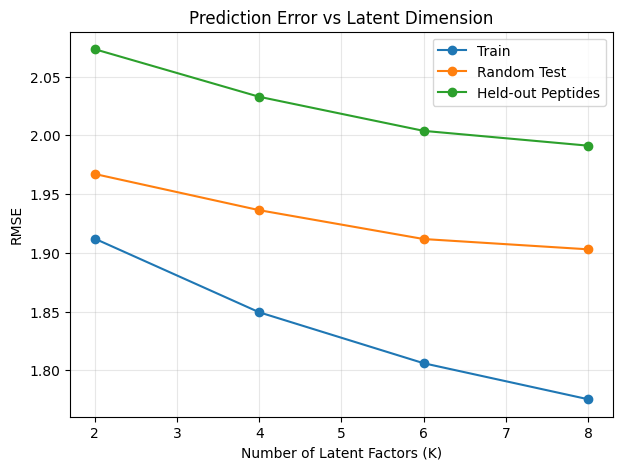

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(metrics_df["K"], metrics_df["train_rmse"], marker="o", label="Train")
plt.plot(metrics_df["K"], metrics_df["random_rmse"], marker="o", label="Random Test")
plt.plot(metrics_df["K"], metrics_df["holdout_rmse"], marker="o", label="Held-out Peptides")

plt.xlabel("Number of Latent Factors (K)")
plt.ylabel("RMSE")
plt.title("Prediction Error vs Latent Dimension")
plt.legend()
plt.grid(alpha=0.3)

plt.show()




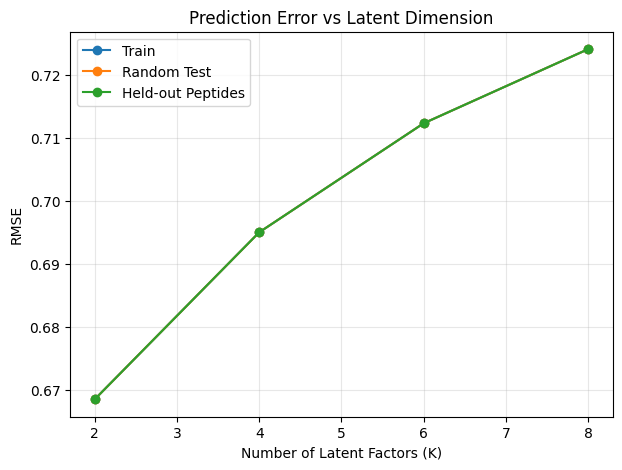

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(metrics_df["K"], metrics_df["train_pearson"], marker="o", label="Train")
plt.plot(metrics_df["K"], metrics_df["train_pearson"], marker="o", label="Random Test")
plt.plot(metrics_df["K"], metrics_df["train_pearson"], marker="o", label="Held-out Peptides")

plt.xlabel("Number of Latent Factors (K)")
plt.ylabel("RMSE")
plt.title("Prediction Error vs Latent Dimension")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
#Testing on toy model

hpmf_model_wESM = Hybrid_PMF_dev(
        train_df.copy(),
        phys_chem_norm.copy(),
        esm_input_sweep.copy(),
        taxonomy_species.copy(),
        dim=6,
        include_esm=True,
        horseshoe=False,
        hierarchical=True,
        anchor_pc=False
    )

hpmf_model_wESM.idata = hpmf_model_wESM.draw_samples(
        draws=100,      # use small numbers for sweep
        tune=200,
        chains=2,
        nuts_sampler="numpyro"
    )

train_metrics = hpmf_model_wESM.evaluate(train_df)
random_metrics = hpmf_model_wESM.evaluate(random_test)
holdout_metrics = hpmf_model_wESM.evaluate(hold_peptides_test)

U_mean = hpmf_model_wESM.idata.posterior["U"].mean(dim=("chain", "draw")).values


/usr/local/lib/python3.12/dist-packages/pytensor/tensor/blas.py:1727: FutureWarning: batched_dot is deprecated. Use `dot` in conjunction with `tensor.vectorize` or `graph.replace.vectorize_graph`
  warnings.warn(
sample: 100%|██████████| 300/300 [05:19<00:00,  1.07s/it]
/usr/local/lib/python3.12/dist-packages/jax/_src/interpreters/mlir.py:1334: UserWarning: Some donated buffers were not usable: float64[2,100,349].
See an explanation at https://docs.jax.dev/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()


────────────────────────────────────────────────
  N        : 57709
  RMSE     : 1.8013
  Pearson  : r=0.7144  p=0
  Spearman : r=0.6845  p=0
────────────────────────────────────────────────



Output()


────────────────────────────────────────────────
  N        : 14427
  RMSE     : 1.9099
  Pearson  : r=0.6614  p=0
  Spearman : r=0.6306  p=0
────────────────────────────────────────────────



Output()


────────────────────────────────────────────────
  N        : 7669
  RMSE     : 1.9963
  Pearson  : r=0.6530  p=0
  Spearman : r=0.6313  p=0
────────────────────────────────────────────────



In [ ]:
hpmf_test_wESM = Hybrid_PMF_dev(train_df.copy(), phys_chem_norm.copy(), esm_input.copy(),
                        taxonomy_species.copy(), dim=4, include_esm=True, horseshoe=True, hierarchical=True, anchor_pc=True)
    # This evaluates the log-probability of every parameter at its starting value
print(hpmf_test_wESM.model.point_logps())

/usr/local/lib/python3.12/dist-packages/pytensor/tensor/blas.py:1727: FutureWarning: batched_dot is deprecated. Use `dot` in conjunction with `tensor.vectorize` or `graph.replace.vectorize_graph`
  warnings.warn(


{'B_pc': np.float64(-44.11), 'B_pc_anchors': np.float64(-2.9), 'tau_esm': np.float64(-1.14), 'lambda_esm': np.float64(-1465.25), 'B_esm_raw': np.float64(-4704.97), 'V_genus': np.float64(-1286.51), 'V_species': np.float64(-2907.52), 'V_strains': np.float64(-4017.6), 'beta_strain_sigma': np.float64(-0.73), 'beta_genus': np.float64(-320.71), 'beta_species': np.float64(-726.88), 'beta_strain': np.float64(-1004.4), 'w0_pc': np.float64(-11.03), 'w0_esm': np.float64(1771.07), 'sigma_obs': np.float64(-0.73), 'MIC_obs': np.float64(-614786.11)}


In [ ]:
hpmf_model_wESM = Hybrid_PMF_dev(train_df.copy(), phys_chem_norm.copy(), esm_input.copy(),
                        taxonomy_species, dim=4, include_esm=True, horseshoe=True, hierarchical=True, anchor_pc=True)

hpmf_model_wESM.draw_samples(draws=200, tune=300, nuts_sampler="numpyro", chains=2)  # init="jitter+adapt_diag", n_init=50000,


/usr/local/lib/python3.12/dist-packages/pytensor/tensor/blas.py:1727: FutureWarning: batched_dot is deprecated. Use `dot` in conjunction with `tensor.vectorize` or `graph.replace.vectorize_graph`
  warnings.warn(
warmup:  20%|██        | 101/500 [28:07<2:11:02, 19.71s/it]

In [ ]:
# Save posterior samples
hpmf_model_wESM.idata.to_netcdf("hpmf_K4.nc")

# Save dictionaries
import pickle

metadata = {
    "peptide_dict": hpmf_model_wESM.peptide_dict,
    "strain_dict": hpmf_model_wESM.strain_dict,
    "species_dict": hpmf_model_wESM.species_dict,
    "genus_dict": hpmf_model_wESM.genus_dict,
}

with open("hpmf_K4_metadata.pkl", "wb") as f:
    pickle.dump(metadata, f)

NameError: name 'hpmf_model_wESM' is not defined

In [ ]:
import pickle

with open("hpmf_K4_metadata.pkl", "rb") as f:
    metadata = pickle.load(f)

peptide_dict = metadata["peptide_dict"]
strain_dict = metadata["strain_dict"]
species_dict = metadata["species_dict"]
genus_dict = metadata["genus_dict"]

In [ ]:
#getting the means

U_mean = (
    hpmf_model_wESM.idata.posterior["U"]
    .mean(dim=("chain", "draw"))
    .values
)

V_mean = (
    hpmf_model_wESM.idata.posterior["V_species"]
    .mean(dim=("chain", "draw"))
    .values
)

[0.33410236 0.28122401 0.20409066 0.18058297]


Text(0, 0.5, 'Cumulative explained variance')

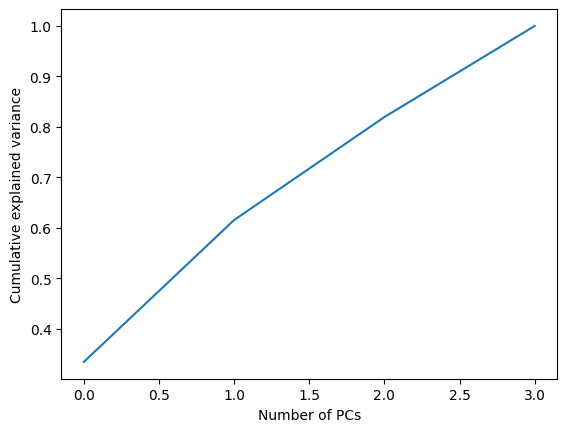

In [ ]:
#Peptide PCA
from sklearn.decomposition import PCA

pca = PCA(n_components = 4)
Z = pca.fit_transform(U_mean)
print(pca.explained_variance_ratio_)

pca = PCA()
pca.fit(U_mean)

cumvar = np.cumsum(pca.explained_variance_ratio_)

plt.plot(cumvar)
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative explained variance")

In [ ]:
peptide_order = [
    peptide
    for peptide, idx in sorted(
        peptide_dict.items(),
        key=lambda x: x[1]
    )
]

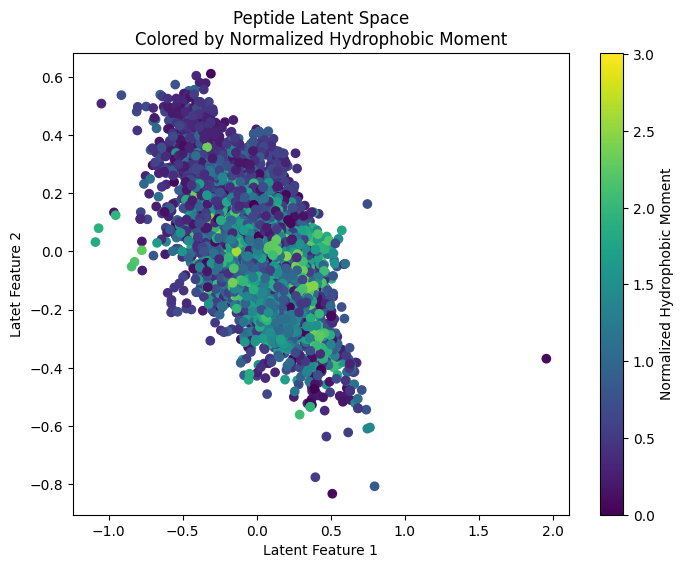

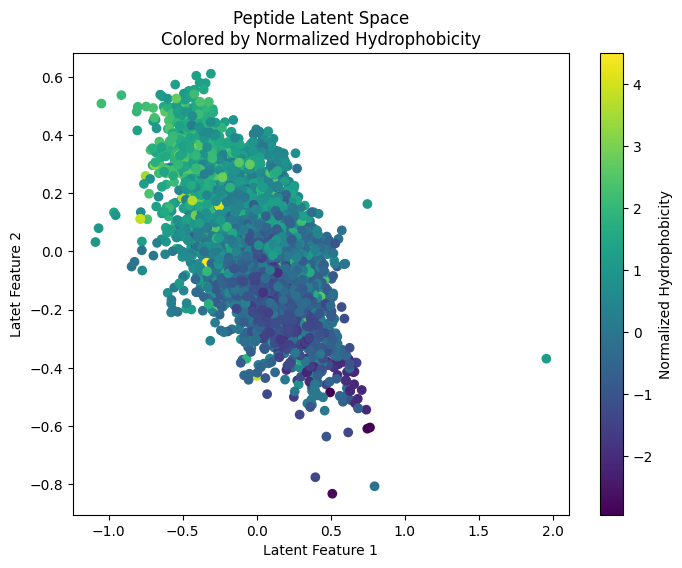

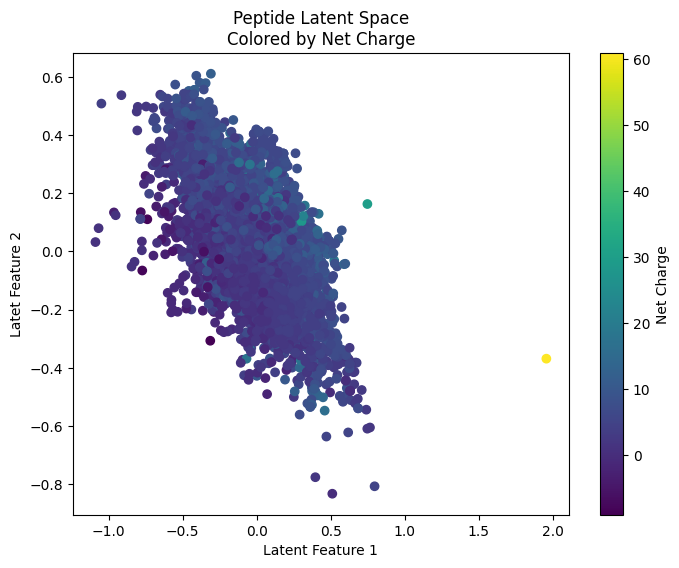

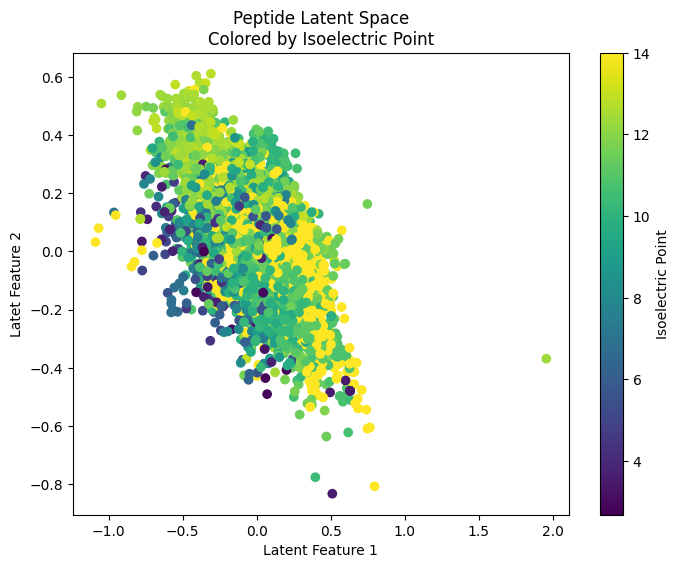

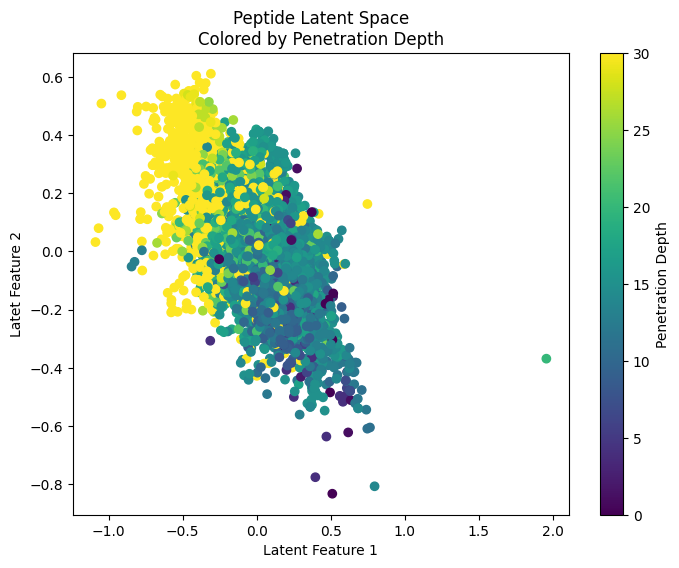

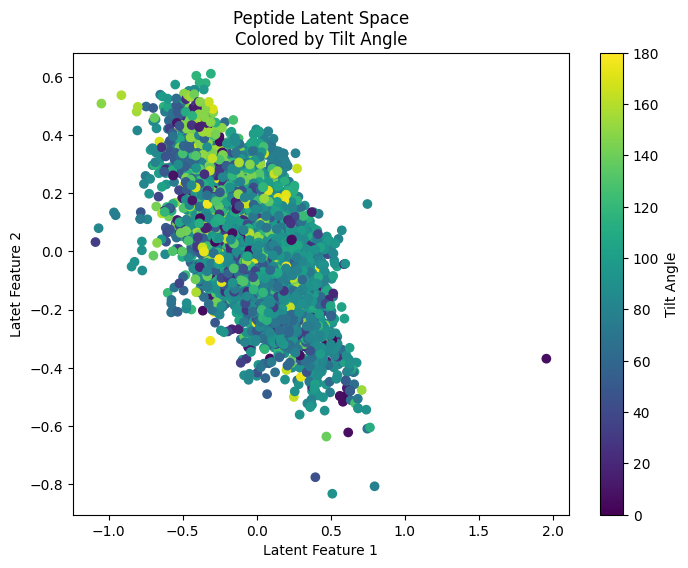

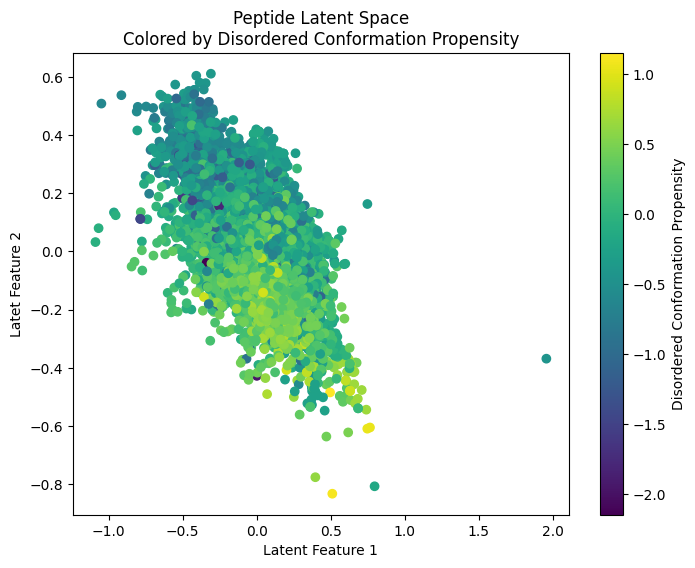

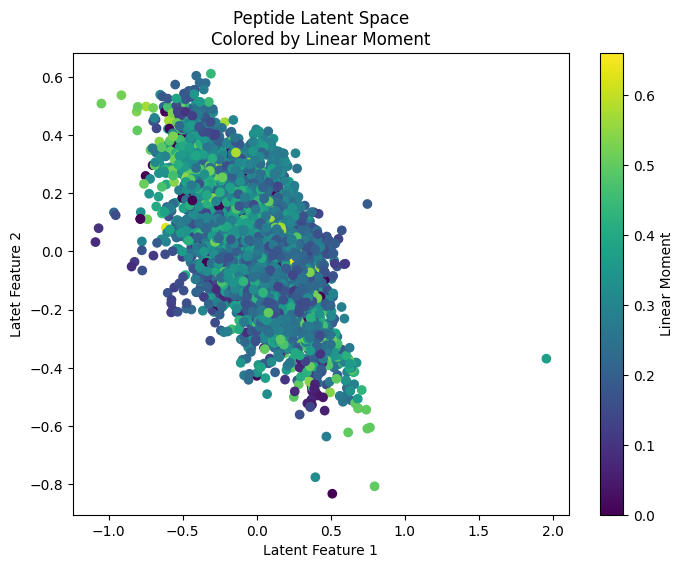

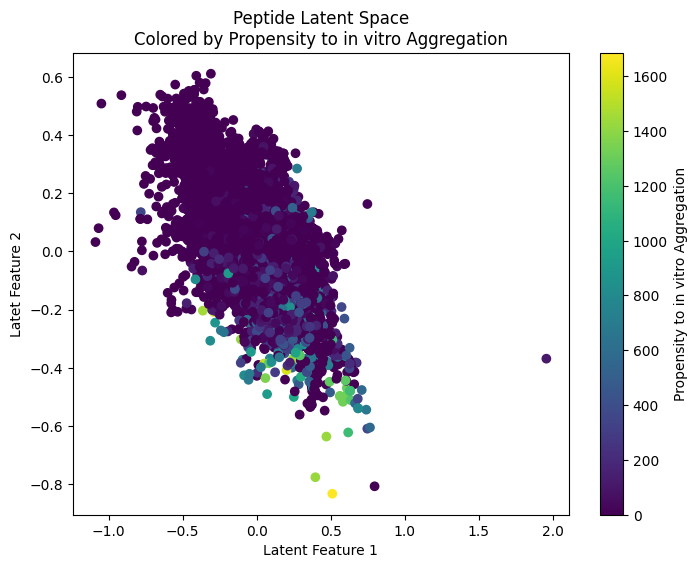

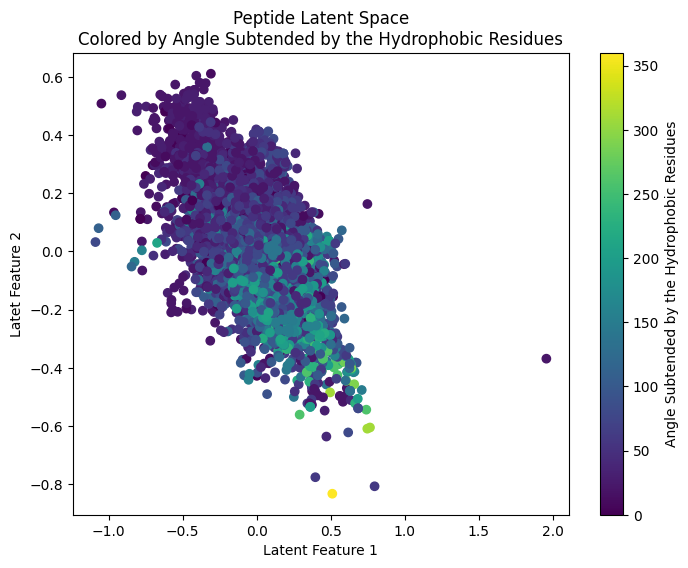

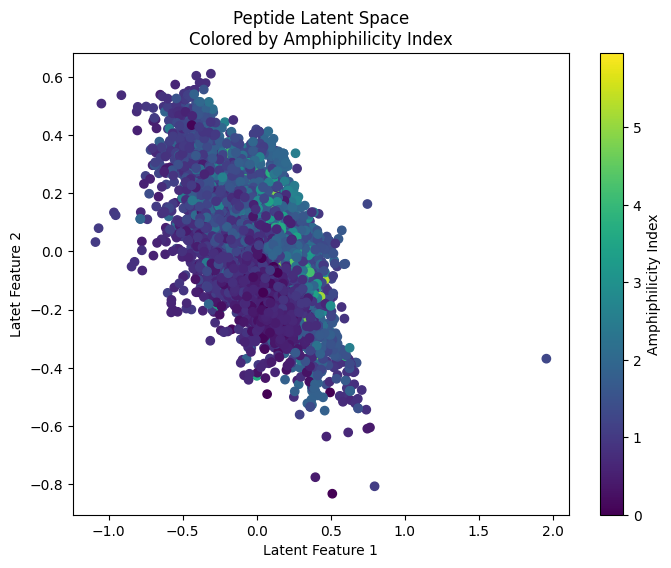

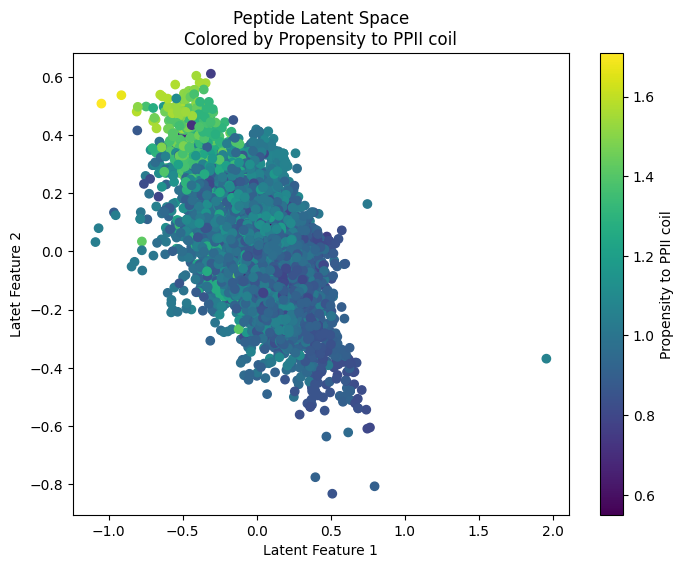

In [ ]:
#First, plotting the scatter plot of top two components from PCA of latent features to observe feature overlap
import matplotlib.pyplot as plt
for feature in all_chem_phys.columns:
  # skip non-numeric columns
  if not np.issubdtype(all_chem_phys[feature].dtype, np.number):
        continue

  plt.figure(figsize=(8,6))

  sc = plt.scatter(
      U_mean[:,0],
      U_mean[:,1],
      c=all_chem_phys.loc[
        peptide_order,
        feature].values
  )

  plt.colorbar(sc, label=feature)
  plt.xlabel("Latent Feature 1")
  plt.ylabel("Latet Feature 2")

  plt.title(f"Peptide Latent Space\nColored by {feature}")

  plt.show()



PC1 seems to have captured most of normalized hydrophobicity.  Charge does not look super encoded (maybe msot not that charged? Isolelectric point is mostly PC2. PC1 also correlated with penetration depth.

In [ ]:
#plotting just three features but for each pca comparison

#First, plotting the scatter plot of top two components from PCA of latent features to observe feature overlap
import matplotlib.pyplot as plt
for feature in all_chem_phys.columns:
  # skip non-numeric columns
  if not np.issubdtype(all_chem_phys[feature].dtype, np.number):
        continue

  plt.figure(figsize=(8,6))

  sc = plt.scatter(
      Z[:,0],
      Z[:,3],
      c=all_chem_phys.loc[
        peptide_order,
        feature].values
  )

  plt.colorbar(sc, label=feature)
  plt.xlabel("PC1")
  plt.ylabel("PC3")

  plt.title(f"PCA of Peptide Latent Space\nColored by {feature}")

  plt.show()

NameError: name 'Z' is not defined

<Figure size 800x600 with 0 Axes>

[0.32519286 0.29827954 0.20706408 0.16946352]


Text(0, 0.5, 'Cumulative explained variance')

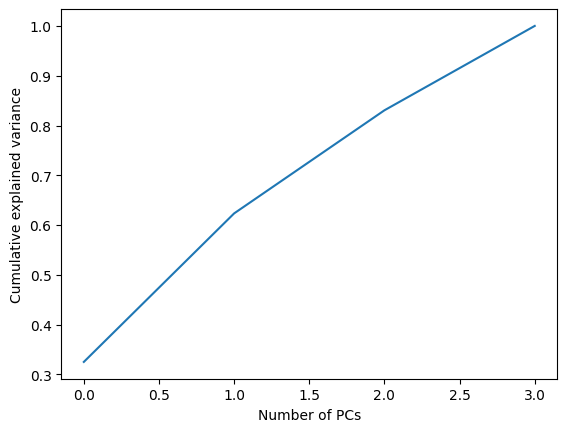

In [ ]:
#Species PCA
from sklearn.decomposition import PCA

pca = PCA(n_components = 4)
Z = pca.fit_transform(V_mean)
print(pca.explained_variance_ratio_)

pca = PCA()
pca.fit(V_mean)

cumvar = np.cumsum(pca.explained_variance_ratio_)

plt.plot(cumvar)
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative explained variance")

In [ ]:
species_order = [
    species
    for species, idx in sorted(
        species_dict.items(),
        key=lambda x: x[1]
    )
]

In [ ]:
species_tax = taxonomy_species.drop_duplicates(subset=['species']).set_index('species').loc[species_order]

NameError: name 'taxonomy_species' is not defined

- don't do pca just look at the features
- think about how to interpret/visualize ecm
- look at different levels of taxonomy
- look at the interaction for each latent factor
- look at the taxonomies of the clustering
- maybe just do a boxplot of gram positive vs gram negative, t-test on the two
- look into the literature
- look into the posterior values
- add k = 0 (linear model) and k = 1 to compare as well

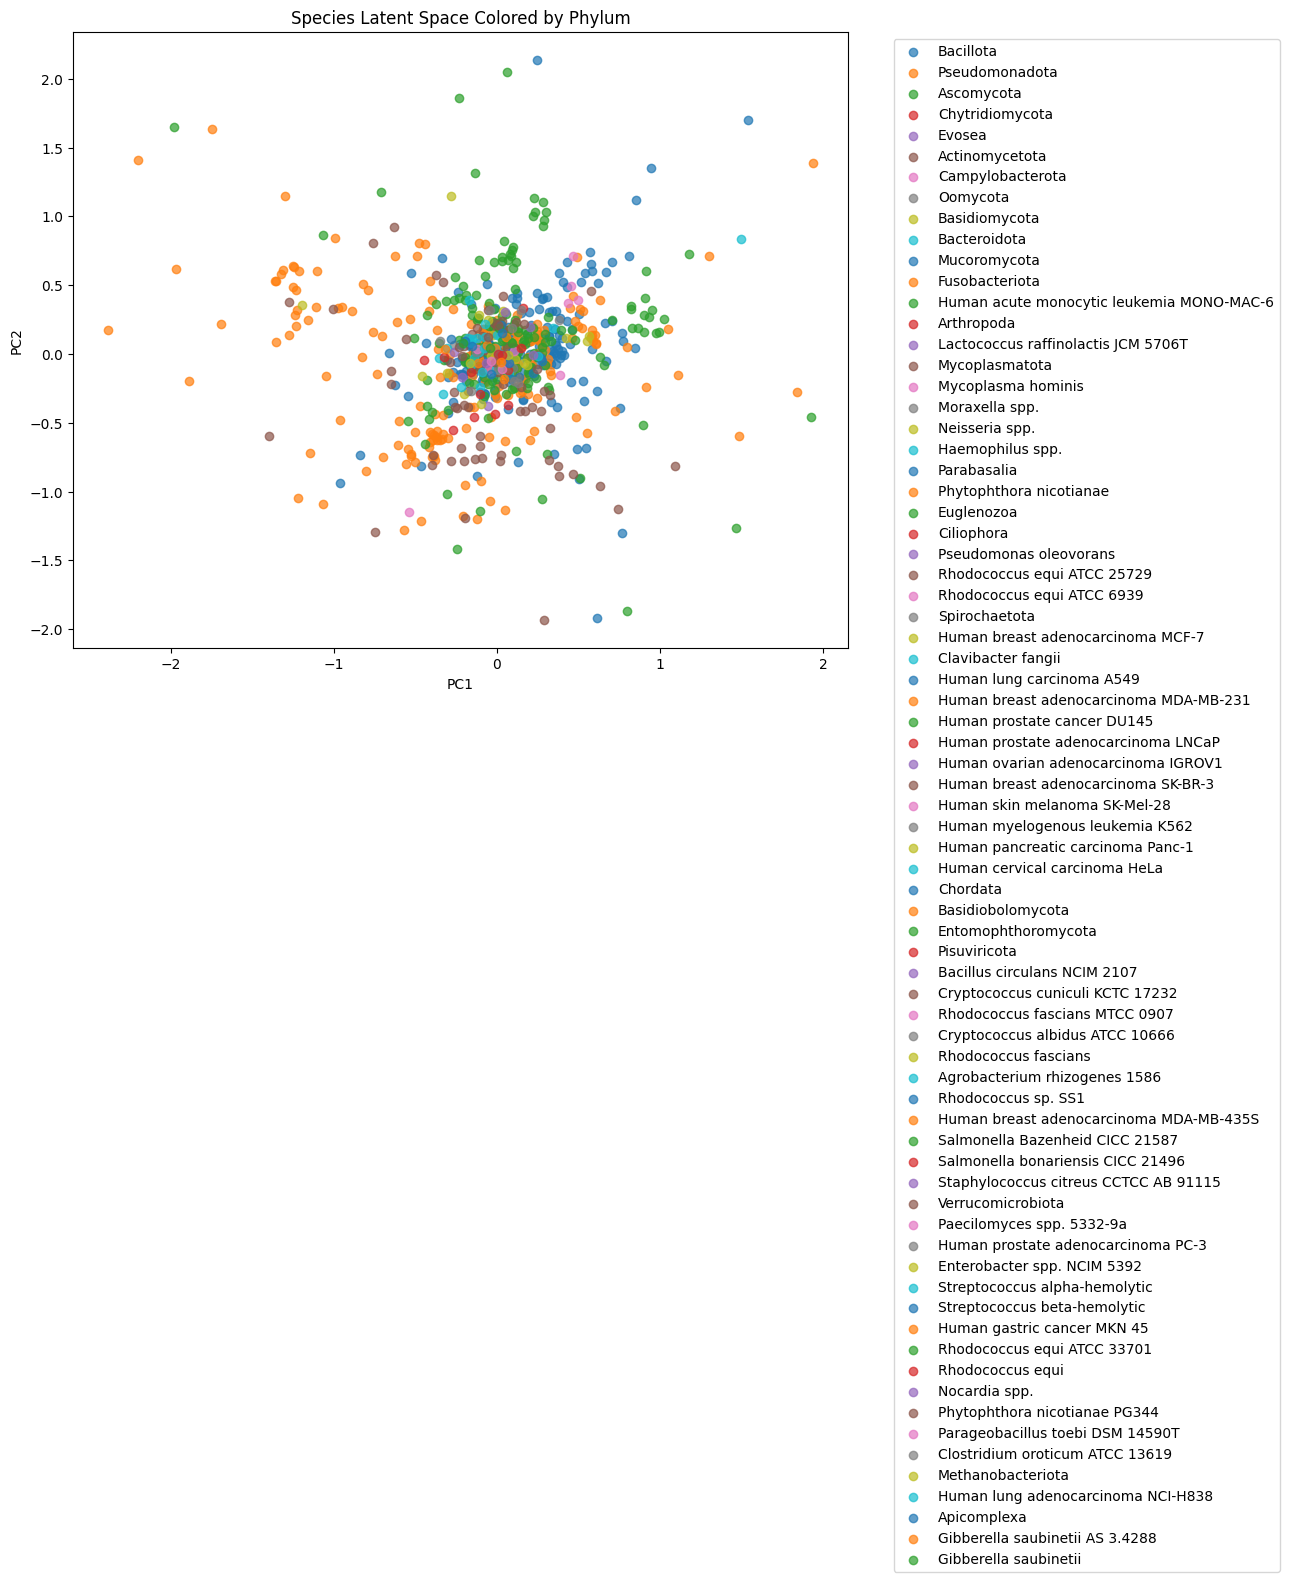

In [ ]:
#plotting the latent space by different phylum's

plt.figure(figsize=(10,8))

for phylum in species_tax["phylum"].unique():

    mask = species_tax["phylum"] == phylum

    plt.scatter(
        Z[mask, 0],
        Z[mask, 1],
        label=phylum,
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Species Latent Space Colored by Phylum")

plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


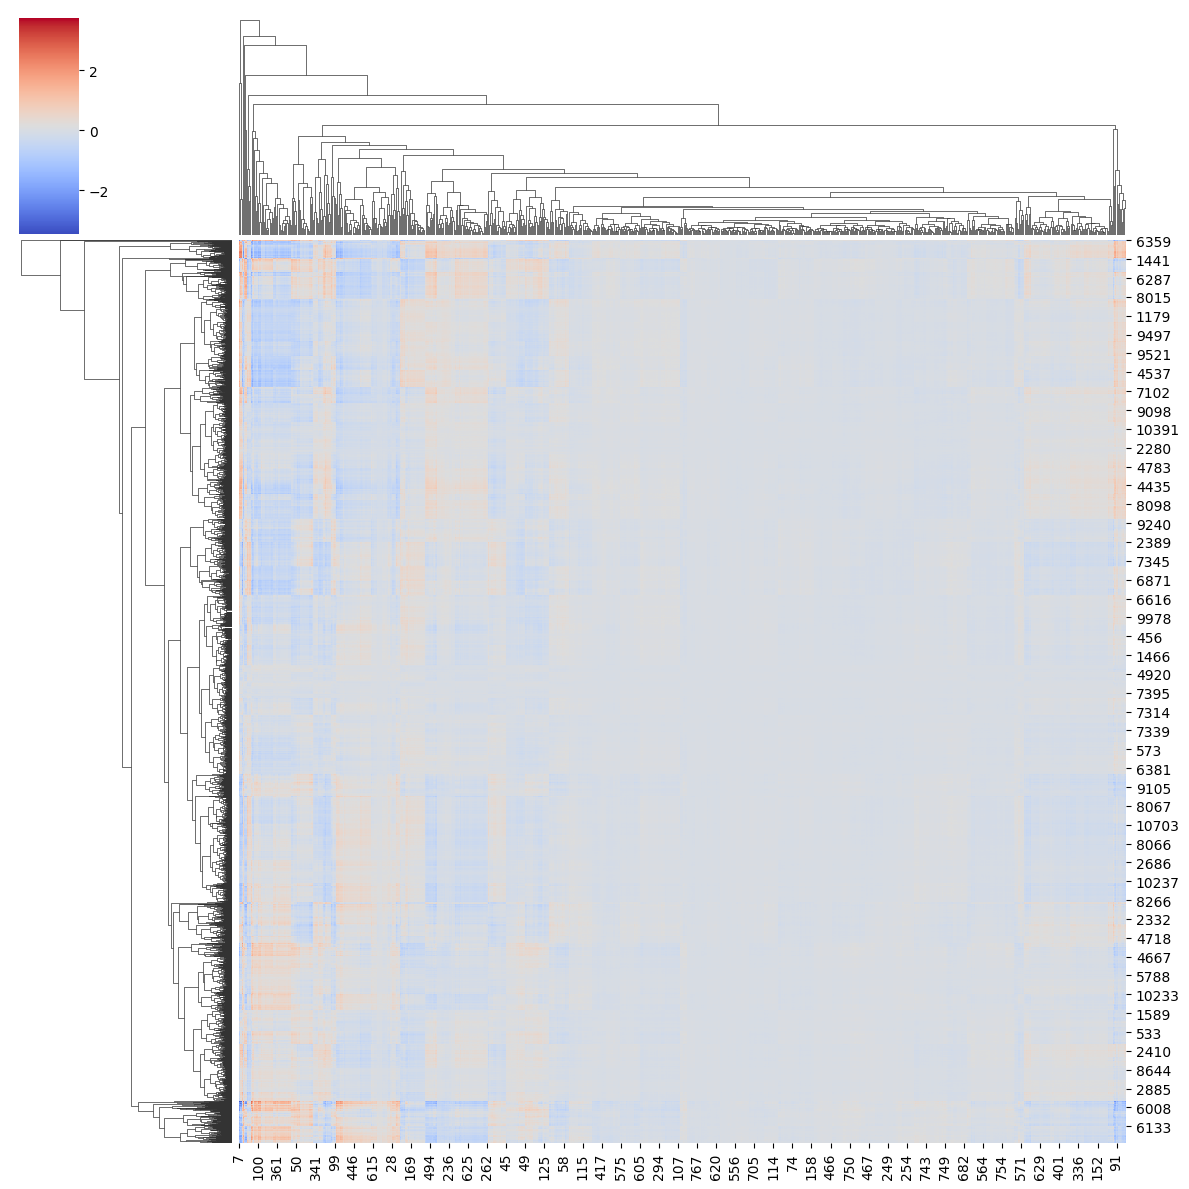

In [ ]:
#heatmap between the dot product of latent species
interaction_matrix = U_mean @ V_mean.T

import seaborn as sns

sns.clustermap(
    interaction_matrix,
    cmap="coolwarm",
    figsize=(12,12)
)

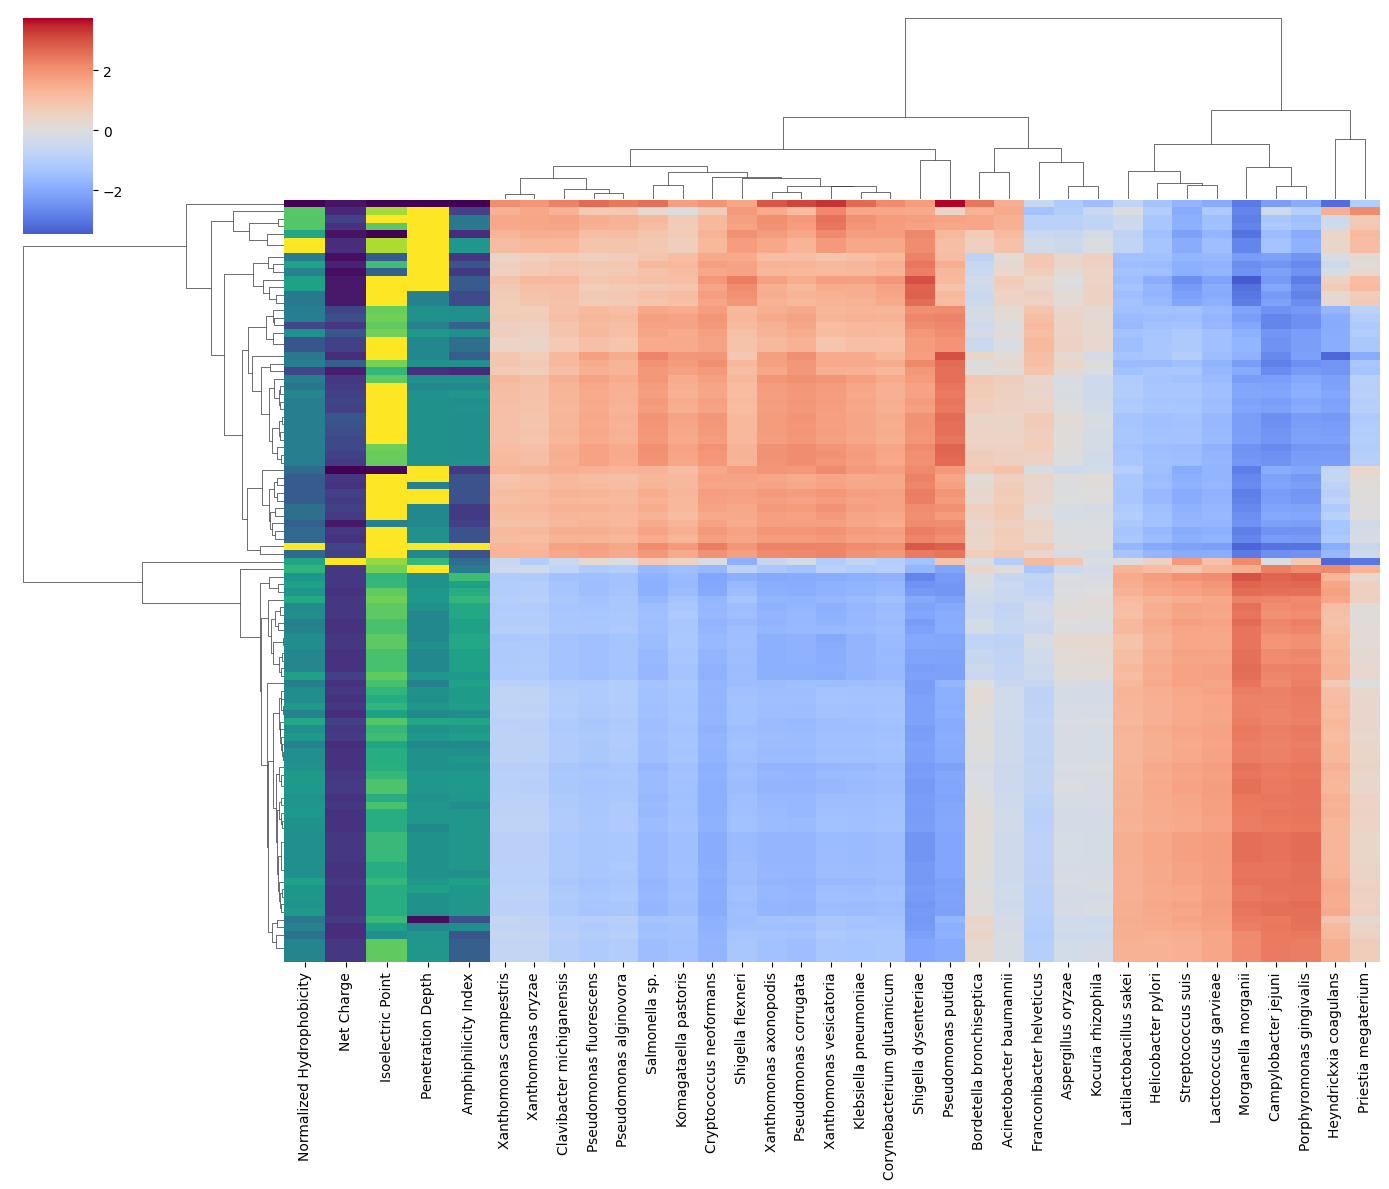

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

features = [
    "Normalized Hydrophobicity",
    "Net Charge",
    "Isoelectric Point",
    "Penetration Depth",
    "Amphiphilicity Index"
]

# build row colors
row_colors = pd.DataFrame(index=top_peptides)

for feature in features:

    vals = peptide_features.loc[top_peptides, feature]

    norm = mcolors.Normalize(
        vmin=vals.min(),
        vmax=vals.max()
    )

    cmap = cm.viridis

    row_colors[feature] = [
        mcolors.to_hex(cmap(norm(v)))
        for v in vals
    ]

g = sns.clustermap(
    interaction_df.loc[top_peptides, top_species],
    cmap="coolwarm",
    center=0,
    row_colors=row_colors,
    figsize=(14,12),
    xticklabels=True,
    yticklabels=False,
    colors_ratio=(0.03,0.03)
)

plt.show()


for i, feature in enumerate(features):

    vals = peptide_features.loc[top_peptides, feature]

    norm = plt.Normalize(vals.min(), vals.max())

    sm = plt.cm.ScalarMappable(
        cmap="viridis",
        norm=norm
    )

    sm.set_array([])

    cax = g.fig.add_axes([1.02, 0.75 - i*0.12, 0.02, 0.08])

    cb = plt.colorbar(sm, cax=cax)

    cb.set_label(feature)

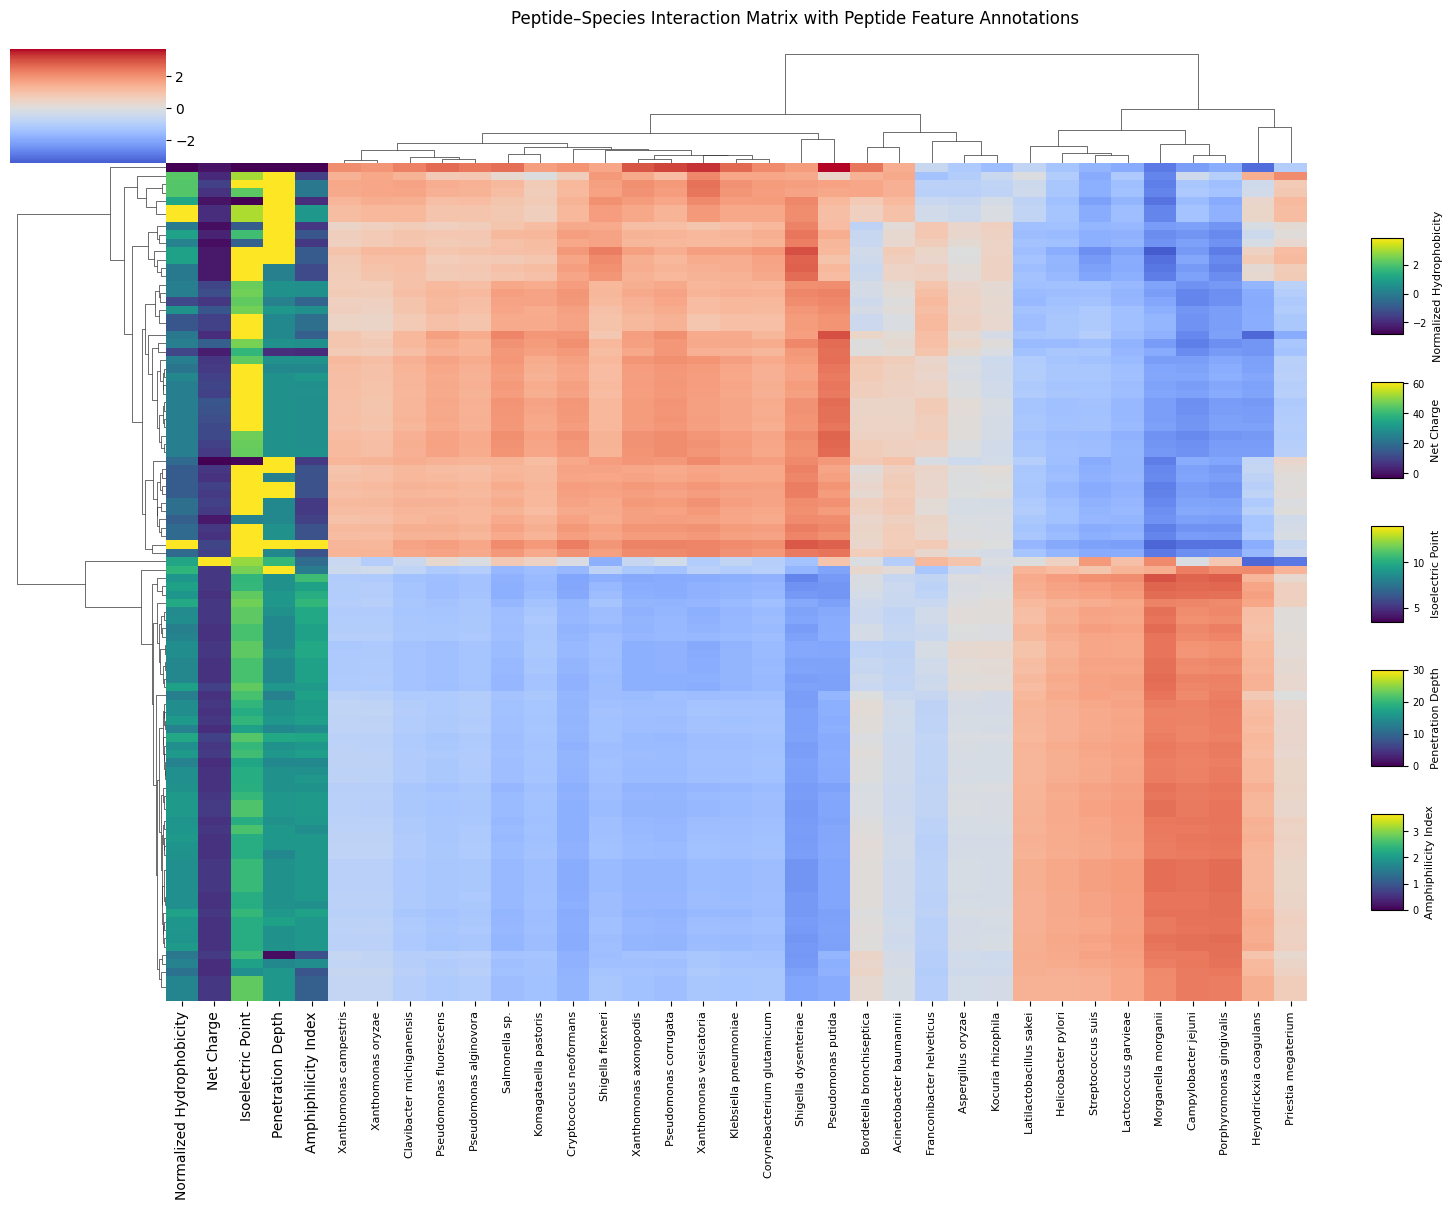

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.preprocessing import minmax_scale

features = [
    "Normalized Hydrophobicity",
    "Net Charge",
    "Isoelectric Point",
    "Penetration Depth",
    "Amphiphilicity Index",
]

# Build row color strips
row_colors = pd.DataFrame(index=top_peptides)
feature_norms = {}

for feature in features:
    vals = peptide_features.loc[top_peptides, feature].astype(float)

    norm = mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
    feature_norms[feature] = norm

    row_colors[feature] = [
        mcolors.to_hex(cm.viridis(norm(v)))
        for v in vals
    ]

# Main clustermap
g = sns.clustermap(
    interaction_df.loc[top_peptides, top_species],
    cmap="coolwarm",
    center=0,
    figsize=(16, 12),
    row_colors=row_colors,
    xticklabels=True,
    yticklabels=False,
    colors_ratio=(0.025, 0.025),
    dendrogram_ratio=(0.12, 0.12),
    cbar_pos=(0.02, 0.8, 0.03, 0.15)
)

plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=8)

# Make room on right side for feature colorbars
g.fig.subplots_adjust(right=0.82)

# Add separate colorbars for peptide features
for i, feature in enumerate(features):
    sm = cm.ScalarMappable(
        cmap="viridis",
        norm=feature_norms[feature]
    )
    sm.set_array([])

    cax = g.fig.add_axes([0.86, 0.75 - i * 0.12, 0.02, 0.08])
    cb = g.fig.colorbar(sm, cax=cax)
    cb.set_label(feature, fontsize=8)
    cb.ax.tick_params(labelsize=7)

g.fig.suptitle(
    "Peptide–Species Interaction Matrix with Peptide Feature Annotations",
    y=1.02
)

plt.show()

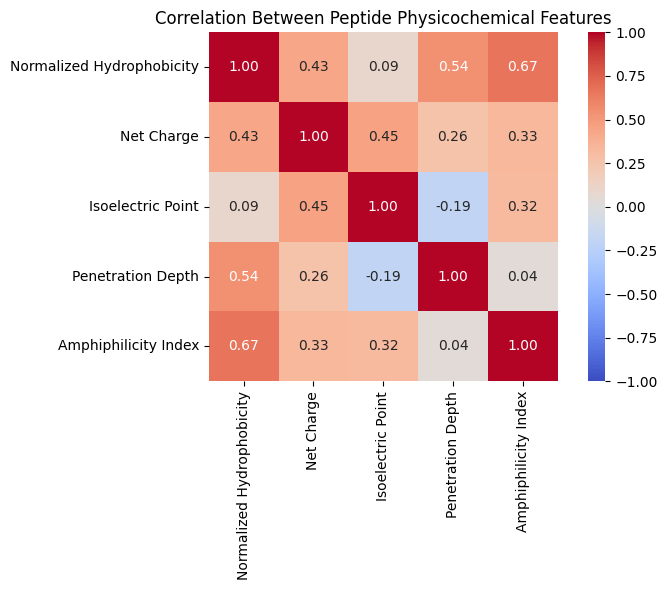

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    "Normalized Hydrophobicity",
    "Net Charge",
    "Isoelectric Point",
    "Penetration Depth",
    "Amphiphilicity Index",
]

peptide_feature_df = all_chem_phys.loc[
    peptide_order,
    features
].astype(float)

corr = peptide_feature_df.corr(method="pearson")

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    fmt=".2f"
)

plt.title("Correlation Between Peptide Physicochemical Features")
plt.tight_layout()
plt.show()

In [ ]:
print(az.summary(hpmf_model_wESM.idata, group="sample_stats", var_names=["tree_depth", "n_steps", "step_size"]))

                mean   sd    hdi_3%   hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
tree_depth    10.000  0.0    10.000    10.000        0.0      NaN     200.0   
n_steps     1023.000  0.0  1023.000  1023.000        0.0      NaN     200.0   
step_size      0.004  0.0     0.004     0.004        0.0      0.0       2.0   

            ess_tail        r_hat  
tree_depth     200.0          NaN  
n_steps        200.0          NaN  
step_size        2.0  22822228.94  


/usr/local/lib/python3.12/dist-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/usr/local/lib/python3.12/dist-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


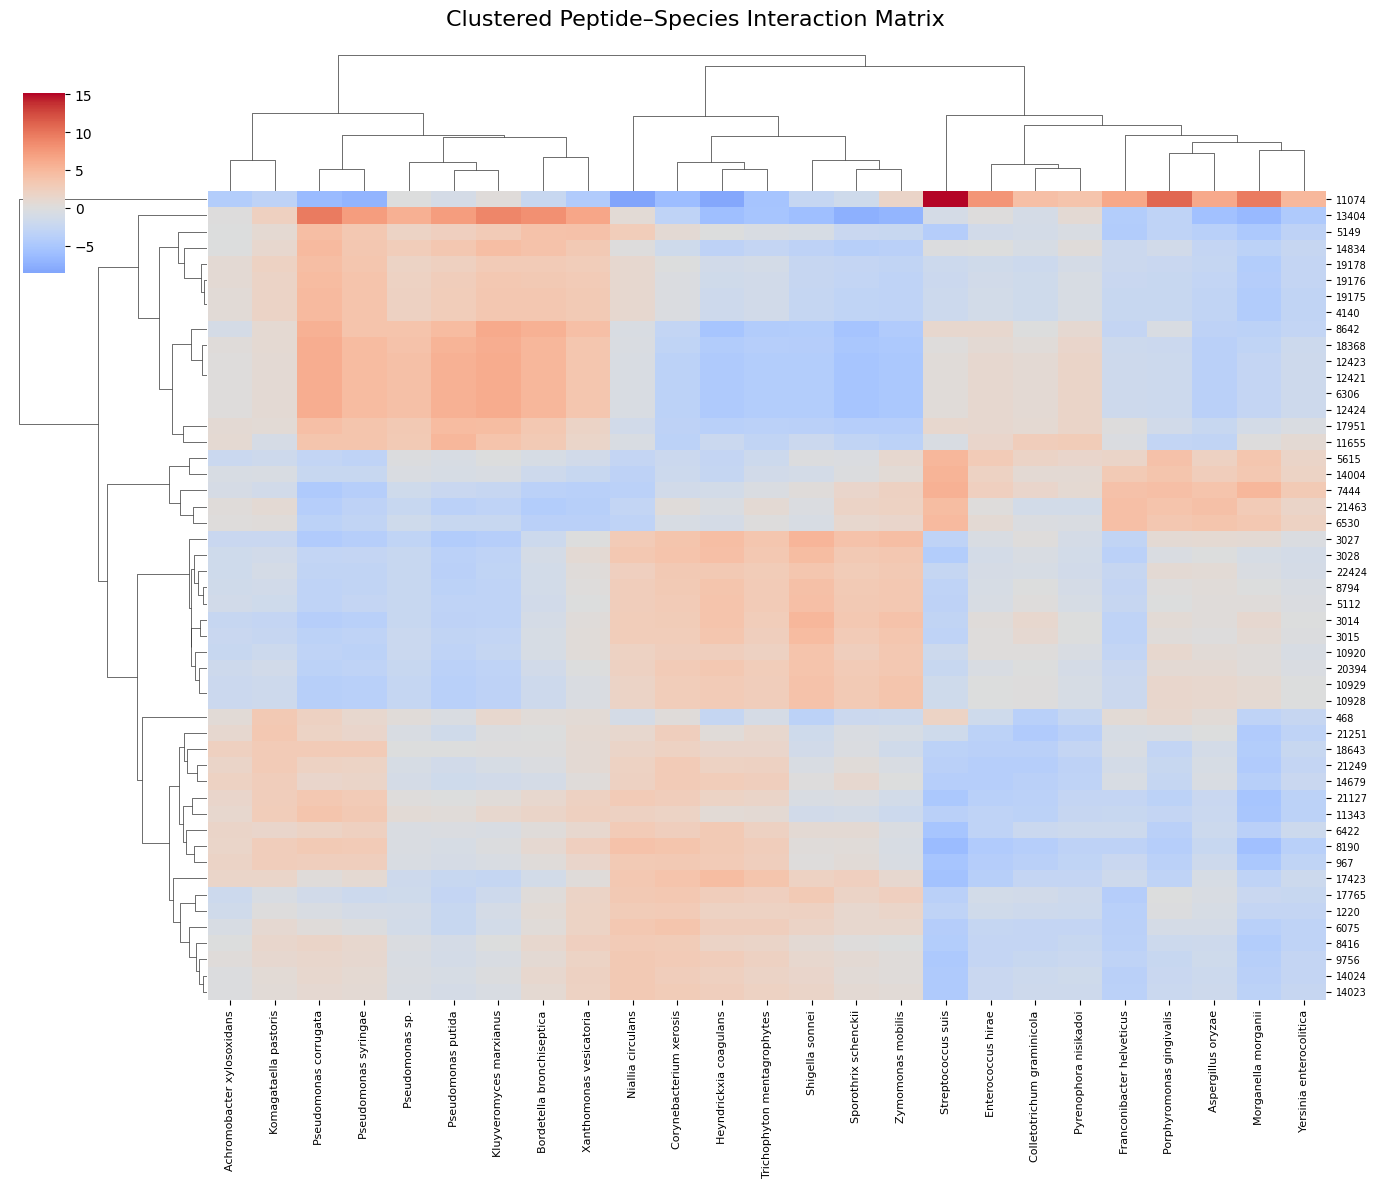

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------------------------------
# Interaction matrix
# --------------------------------------------------

interaction_matrix = U_mean @ V_mean.T

interaction_df = pd.DataFrame(
    interaction_matrix,
    index=peptide_order,
    columns=species_order   # or strain_order if appropriate
)

# --------------------------------------------------
# Smaller interpretable subset
# --------------------------------------------------

top_n_peptides = 50
top_n_species = 25

# peptides with strongest interactions
top_peptides = (
    interaction_df.abs()
    .mean(axis=1)
    .sort_values(ascending=False)
    .head(top_n_peptides)
    .index
)

# species with strongest interactions
top_species = (
    interaction_df.abs()
    .mean(axis=0)
    .sort_values(ascending=False)
    .head(top_n_species)
    .index
)

interaction_subset = interaction_df.loc[
    top_peptides,
    top_species
]

# --------------------------------------------------
# Clustered heatmap
# --------------------------------------------------

g = sns.clustermap(
    interaction_subset,
    cmap="coolwarm",
    center=0,
    figsize=(14, 12),

    xticklabels=True,
    yticklabels=True,

    linewidths=0,

    dendrogram_ratio=(0.15, 0.15),
    cbar_pos=(0.02, 0.8, 0.03, 0.15)
)

# rotate labels for readability
plt.setp(
    g.ax_heatmap.get_xticklabels(),
    rotation=90,
    fontsize=8
)

plt.setp(
    g.ax_heatmap.get_yticklabels(),
    fontsize=7
)

g.fig.suptitle(
    "Clustered Peptide–Species Interaction Matrix",
    y=1.02,
    fontsize=16
)

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Posterior means
# ---------------------------------------------------

post = hpmf_model_wESM.idata.posterior

alpha_mean = (
    post["alpha_peptide"]
    .mean(dim=("chain", "draw"))
    .values
)

beta_mean = (
    post["beta_strain"]   # or beta_species
    .mean(dim=("chain", "draw"))
    .values
)

U_mean = (
    post["U"]
    .mean(dim=("chain", "draw"))
    .values
)

V_mean = (
    post["V_strains"]     # or V_species
    .mean(dim=("chain", "draw"))
    .values
)

latent_effect = U_mean @ V_mean.T

# ---------------------------------------------------
# helper function
# ---------------------------------------------------

def top_bottom_means(arr, frac=0.10):

    flat = np.sort(arr.flatten())

    n = len(flat)
    k = int(frac * n)

    bottom_mean = flat[:k].mean()
    top_mean = flat[-k:].mean()

    return bottom_mean, top_mean

# ---------------------------------------------------
# summaries
# ---------------------------------------------------

alpha_bottom, alpha_top = top_bottom_means(alpha_mean)
beta_bottom, beta_top = top_bottom_means(beta_mean)
latent_bottom, latent_top = top_bottom_means(latent_effect)

component_summary = pd.DataFrame({

    "Component": [
        "Peptide intercept",
        "Species/strain intercept",
        "Latent interaction"
    ],

    "Mean": [
        np.mean(alpha_mean),
        np.mean(beta_mean),
        np.mean(latent_effect)
    ],

    "SD": [
        np.std(alpha_mean),
        np.std(beta_mean),
        np.std(latent_effect)
    ],

    "Bottom 10% mean": [
        alpha_bottom,
        beta_bottom,
        latent_bottom
    ],

    "Top 10% mean": [
        alpha_top,
        beta_top,
        latent_top
    ]
})

print(component_summary)

# ---------------------------------------------------
# plotting
# ---------------------------------------------------

plot_df = component_summary.melt(
    id_vars="Component",
    value_vars=[
        "Mean",
        "Bottom 10% mean",
        "Top 10% mean"
    ],
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=plot_df,
    x="Component",
    y="Value",
    hue="Metric"
)

plt.axhline(0, color="black", linewidth=1)

plt.ylabel("Effect magnitude on centered log2(MIC) scale")

plt.title(
    "Relative Magnitude of Intercepts vs Latent Interaction Effects"
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

NameError: name 'hpmf_model_wESM' is not defined

In [ ]:
hpmf_model_wESM.idata.posterior

In [ ]:
hpmf_model_wESM.idata.to_netcdf("/content/drive/MyDrive/STATS305c/saved_models/full_esm_model.5_14.all_data_horseshoe_prior.nc")

In [ ]:
hpmf_model_wESM_idata = az.from_netcdf(os.path.join(file_path, "ecm_model.nc"))

In [ ]:
hpmf_model_wESM = Hybrid_PMF(train_df.copy(), phys_chem_norm.copy(), esm_pca_input.copy(),
                        None, dim=10, include_esm=True, horseshoe=False)
hpmf_model_wESM.idata = hpmf_model_wESM_idata

In [ ]:

hpmf_model_wESM.evaluate(train_df)
hpmf_model_wESM.evaluate(random_test)
hpmf_model_wESM.evaluate(hold_peptides_test)


Output()


────────────────────────────────────────────────
  N        : 24037
  RMSE     : 1.6433
  Pearson  : r=0.6975  p=0
  Spearman : r=0.6666  p=0
────────────────────────────────────────────────



Output()

Output()


────────────────────────────────────────────────
  N        : 6009
  RMSE     : 1.8767
  Pearson  : r=0.5825  p=0
  Spearman : r=0.5496  p=0
────────────────────────────────────────────────




────────────────────────────────────────────────
  N        : 3307
  RMSE     : 1.9253
  Pearson  : r=0.5568  p=1.22e-268
  Spearman : r=0.5125  p=5.15e-221
────────────────────────────────────────────────



{'n': 3307,
 'rmse': np.float64(1.9253122713429163),
 'pearson_r': np.float64(0.5567831711183301),
 'pearson_p': np.float64(1.2208591668753573e-268),
 'spearman_r': np.float64(0.512545408591133),
 'spearman_p': np.float64(5.147500713969962e-221)}

In [ ]:
diagnose_mcmc(hpmf_model_wESM.idata, label="wESM_PCA")

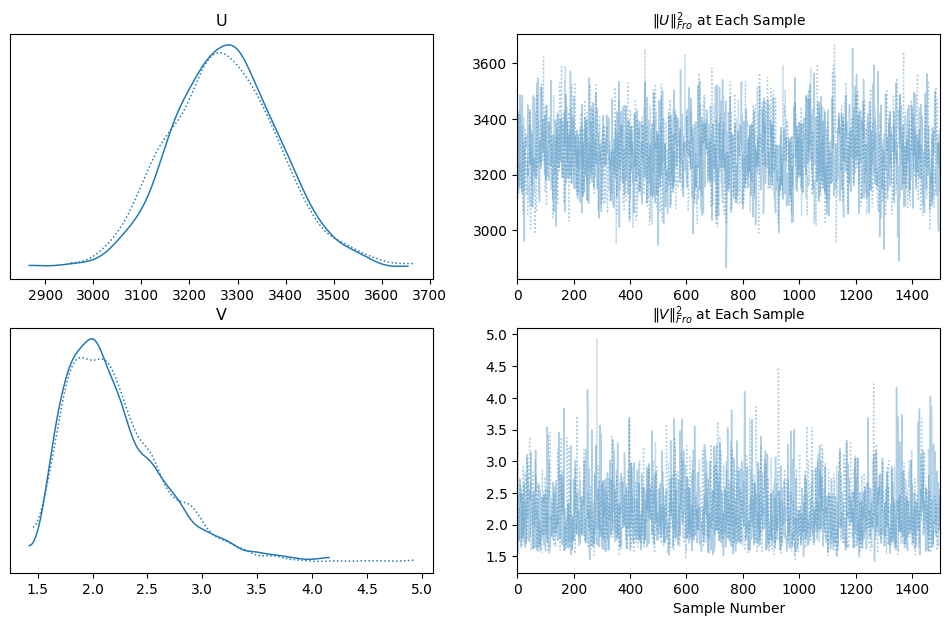

In [ ]:

hpmf_model_wESM.traceplot()

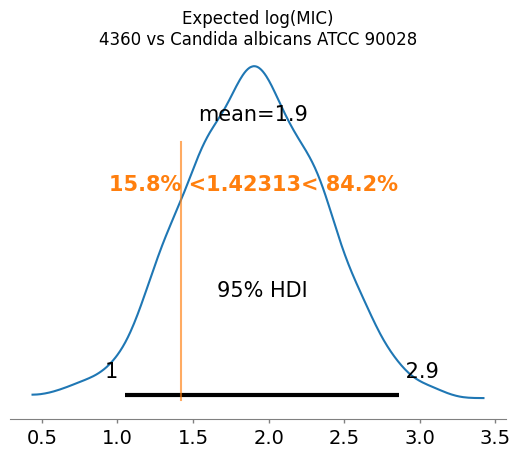

In [ ]:
true_mic = train_df.iloc[14]
peptide_id = true_mic['Peptide ID']
species_id = true_mic['Target Species']
true_mic = true_mic['mic']

hpmf_model_wESM.plot_mic_posterior(peptide_id, species_id, true_mic=true_mic)

plt.savefig(os.path.join(file_path, "random_posterior_y.png"), bbox_inches="tight")

In [ ]:

y_pred = hpmf_model_wESM.predict_new_peptides(train_df)
y_true = train_df["mic"].values
# return compute_metrics(y_true, y_pred, label=label)

Output()

In [ ]:
mse = (y_true - y_pred)**2
worst_prediction = np.argmax(mse)
worst_prediction

np.int64(621)

In [ ]:

train_df['mse'] = mse

In [ ]:

train_df.groupby('Target Species')['mse'].describe().sort_values('mean')

,count,mean,std,min,25%,50%,75%,max
Target Species,,,,,,,,
Pseudomonas aeruginosa KCTC 1637,225.0,1.183226,1.549491,0.000013,0.148226,0.631548,1.534756,9.034171
Human breast adenocarcinoma MDA-MB-231,88.0,1.209592,2.568314,0.000004,0.047589,0.219281,1.055632,16.660467
Bacillus subtilis KCTC 3068,184.0,1.217445,1.886954,0.000053,0.100997,0.541550,1.541504,13.106851
Escherichia coli KCTC 1682,238.0,1.300880,1.905563,0.000087,0.103456,0.412532,1.953932,13.839781
Staphylococcus epidermidis KCTC 1917,210.0,1.367051,2.192597,0.000367,0.131472,0.523485,1.659244,15.161338
...,...,...,...,...,...,...,...,...
Escherichia coli DH5alpha,276.0,3.692637,8.207174,0.000017,0.195831,1.256186,3.892218,86.634863
Staphylococcus aureus ATCC 6538,434.0,3.694414,5.594978,0.000020,0.349572,1.392285,4.656168,52.309479
Staphylococcus aureus ATCC 25923,1878.0,3.784090,6.844965,0.000004,0.356823,1.597584,4.521914,80.948589


<Axes: xlabel='count', ylabel='mean'>

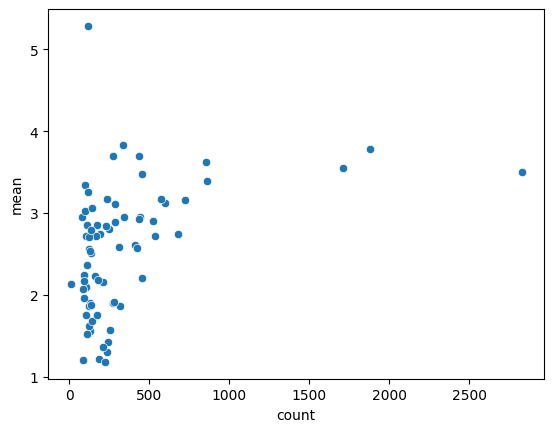

In [ ]:
import seaborn as sns
tmp_mse_species = train_df.groupby('Target Species')['mse'].describe()
sns.scatterplot(tmp_mse_species, x='count', y='mean')

<Axes: xlabel='count', ylabel='std'>

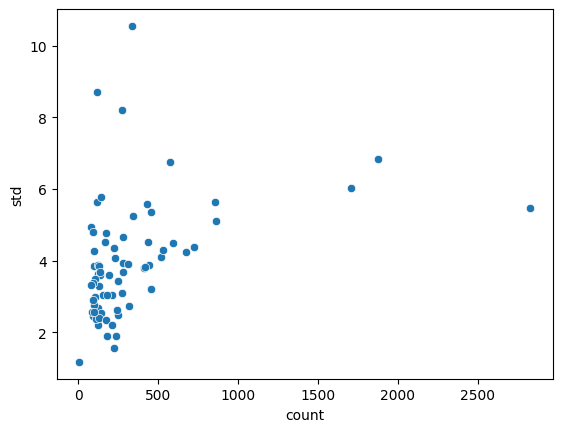

In [ ]:

sns.scatterplot(tmp_mse_species, x='count', y='std')

<Axes: xlabel='count', ylabel='max'>

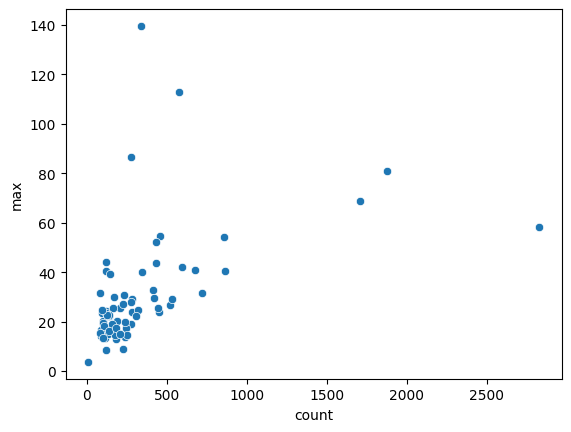

In [ ]:

sns.scatterplot(tmp_mse_species, x='count', y='max')

<Axes: xlabel='mean', ylabel='std'>

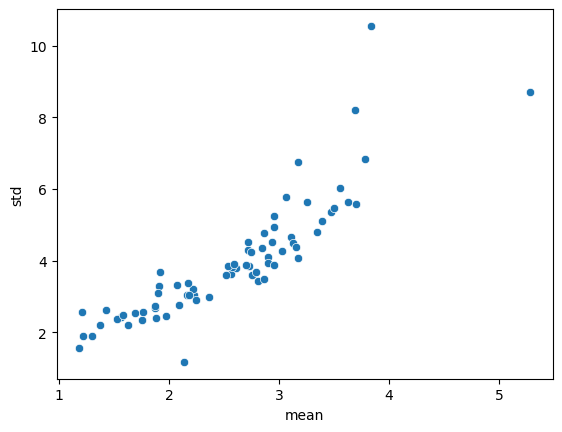

In [ ]:

sns.scatterplot(tmp_mse_species, x='mean', y='std')

(<xarray.DataArray 'x' (chain: 2, draw: 1500)> Size: 24kB
 array([[-1.36035165, -1.46498841, -0.62816271, ..., -0.91140945,
         -2.347068  , -2.15705091],
        [-0.39182352, -0.47397037,  0.20020502, ...,  0.87334831,
         -2.36250164, -2.88223171]])
 Coordinates:
   * chain    (chain) int64 16B 0 1
   * draw     (draw) int64 12kB 0 1 2 3 4 5 6 ... 1494 1495 1496 1497 1498 1499
     peptide  int64 8B 0
     species  int64 8B 0,
 <Axes: title={'center': 'Expected log(MIC)\n4353 vs Bacillus subtilis'}>)

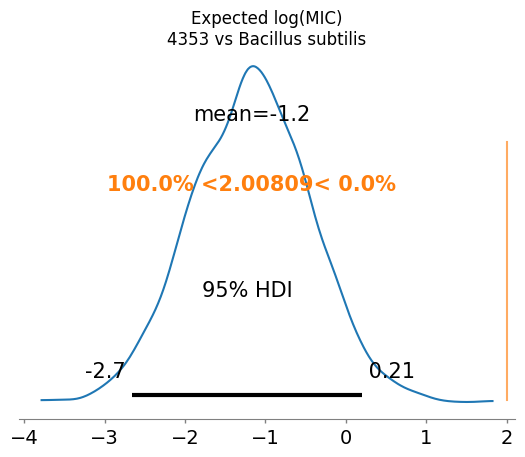

In [ ]:

true_mic = train_df.iloc[0]
peptide_id = true_mic['Peptide ID']
species_id = true_mic['Target Species']
true_mic = true_mic['mic']

hpmf_model_wESM.plot_mic_posterior(peptide_id, species_id, true_mic=true_mic)

In [ ]:

hpmf_model_wESM.evaluate(train_df)

AttributeError: 'str' object has no attribute 'size'

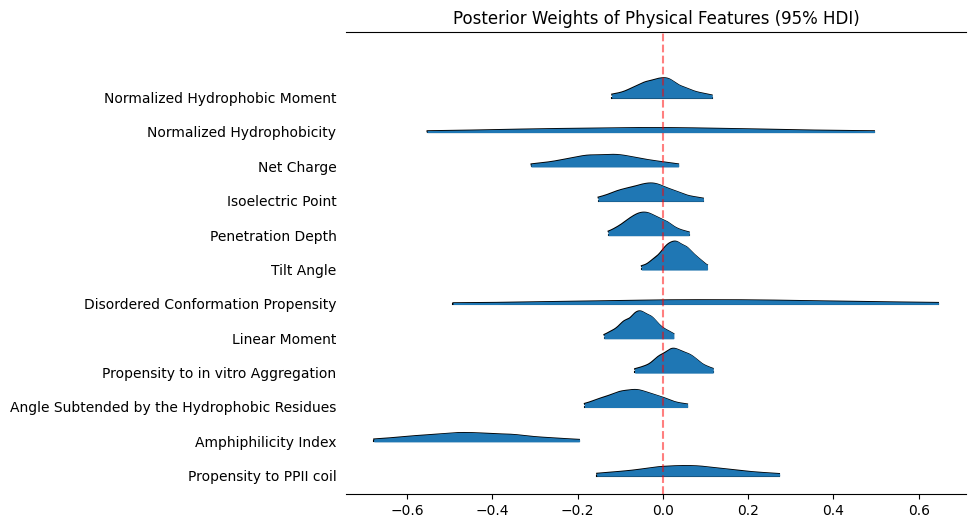

In [ ]:

hpmf_model_wESM.plot_feature_weights(kind="ridgeplot")
plt.savefig(os.path.join(file_path, "hpmf_model_wESM.w0_pc.ridgeplot.png"), bbox_inches="tight")

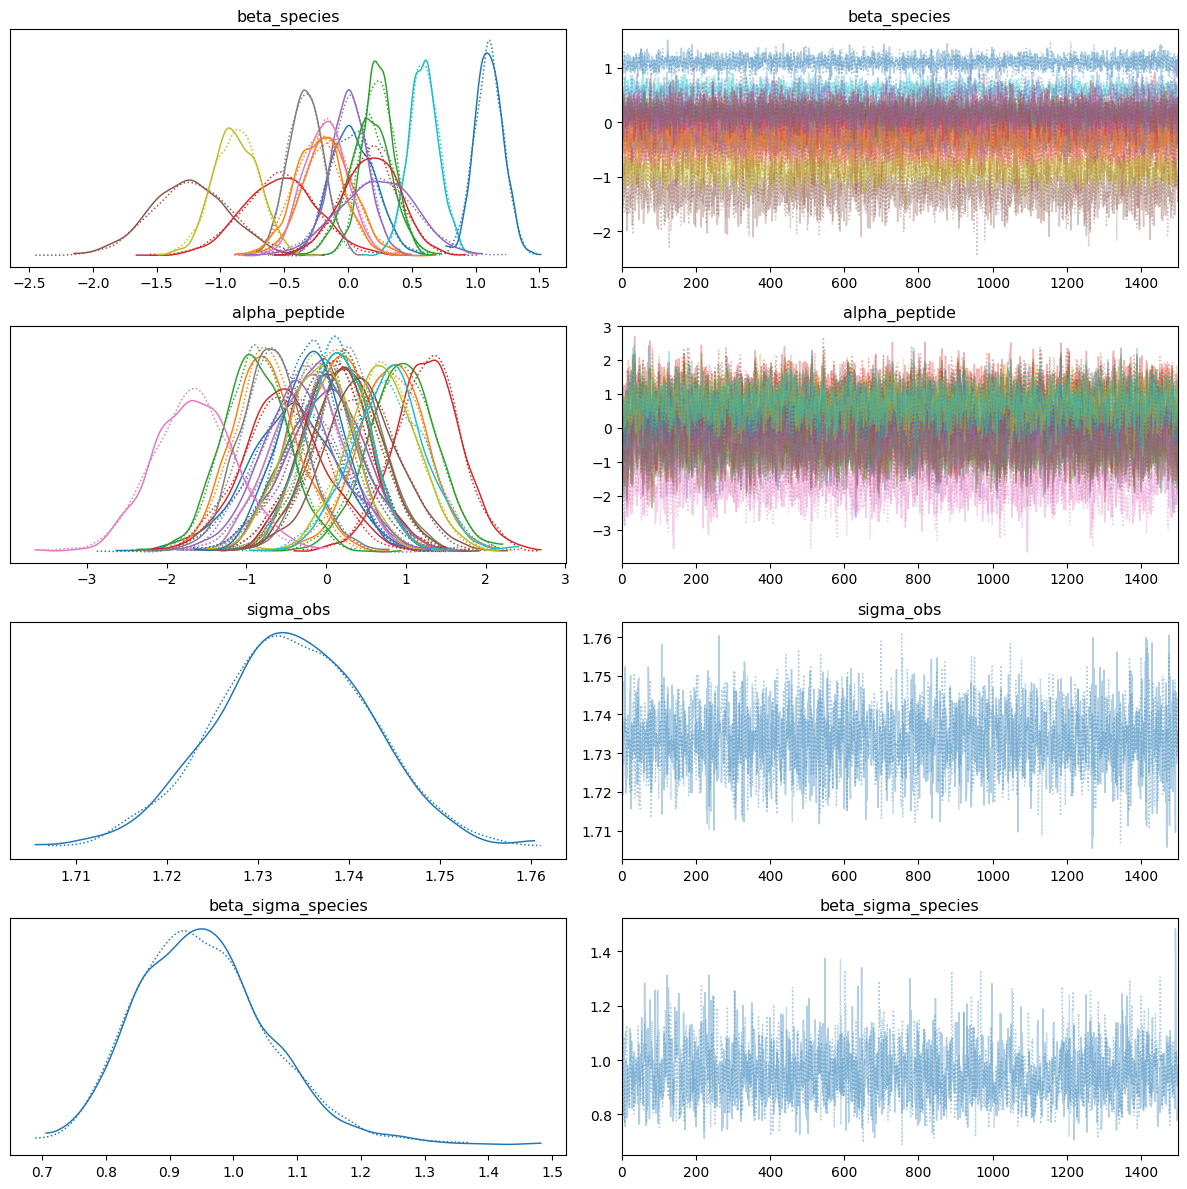

In [ ]:

hpmf_model_wESM.plot_intercept_traces(
    species_list=top_species[:15],
    peptide_list=train_df['Peptide ID'].unique()[:30]
)

In [ ]:

hpmf_model_wESM.plot_mic_posterior(test_mic['Peptide ID'].unique()[0], top_species[0], true_mic=3.5)

In [ ]:
hpmf_lin_model_wESM = Hybrid_PMF(train_df.copy(), phys_chem_norm.copy(), esm_pca_input.copy(),
                        None, dim=10, include_esm=True, horseshoe=False, linreg=True)

hpmf_lin_model_wESM.draw_samples(draws=1500, tune=2000, init="advi+adapt_diag", nuts_sampler="numpyro", n_init=50000)

/usr/local/lib/python3.12/dist-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(
sample: 100%|██████████| 3500/3500 [04:19<00:00, 13.51it/s, 127 steps of size 3.39e-02. acc. prob=0.94]
/usr/local/lib/python3.12/dist-packages/jax/_src/interpreters/mlir.py:1334: UserWarning: Some donated buffers were not usable: float64[2,1500,71].
See an explanation at https://docs.jax.dev/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

In [ ]:
hpmf_lin_model_wESM.idata.to_netcdf("/content/drive/MyDrive/STATS305c/linear_ecm_model.nc")

'/content/drive/MyDrive/STATS305c/linear_ecm_model.nc'

In [ ]:

import scipy.stats as stats

hpmf_lin_model_wESM.evaluate(train_df)
hpmf_lin_model_wESM.evaluate(random_test)
hpmf_lin_model_wESM.evaluate(hold_peptides_test)


Output()

Output()


────────────────────────────────────────────────
  N        : 24037
  RMSE     : 1.9871
  Pearson  : r=0.4940  p=0
  Spearman : r=0.4712  p=0
────────────────────────────────────────────────



Output()


────────────────────────────────────────────────
  N        : 6009
  RMSE     : 2.0208
  Pearson  : r=0.4804  p=0
  Spearman : r=0.4507  p=1.45e-298
────────────────────────────────────────────────




────────────────────────────────────────────────
  N        : 3307
  RMSE     : 2.0593
  Pearson  : r=0.4515  p=7.73e-166
  Spearman : r=0.4218  p=7.85e-143
────────────────────────────────────────────────



{'n': 3307,
 'rmse': np.float64(2.0592919321989016),
 'pearson_r': np.float64(0.4514887877316934),
 'pearson_p': np.float64(7.732727672930237e-166),
 'spearman_r': np.float64(0.4218289135650451),
 'spearman_p': np.float64(7.851685246800204e-143)}

In [ ]:

hpmf_model = Hybrid_PMF(train_df.copy(), phys_chem_norm.copy(), esm_pca_input.copy(),
                        None, dim=10, include_esm=False, horseshoe=False)

hpmf_model.draw_samples(draws=1000, tune=1000, init="advi+adapt_diag", nuts_sampler="numpyro", n_init=50000)

/usr/local/lib/python3.12/dist-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(
sample: 100%|██████████| 2000/2000 [11:49<00:00,  2.82it/s, 511 steps of size 1.39e-02. acc. prob=0.90]
/usr/local/lib/python3.12/dist-packages/jax/_src/interpreters/mlir.py:1334: UserWarning: Some donated buffers were not usable: float64[2,1000,19].
See an explanation at https://docs.jax.dev/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

In [ ]:

hpmf_model.evaluate(train_df)
hpmf_model.evaluate(random_test)
hpmf_model.evaluate(hold_peptides_test)

Output()

Output()


────────────────────────────────────────────────
  N        : 15437
  RMSE     : 2.0586
  Pearson  : r=0.3764  p=0
  Spearman : r=0.3589  p=0
────────────────────────────────────────────────



Output()


────────────────────────────────────────────────
  N        : 3859
  RMSE     : 2.1314
  Pearson  : r=0.3340  p=3.51e-101
  Spearman : r=0.3208  p=4.6e-93
────────────────────────────────────────────────




────────────────────────────────────────────────
  N        : 2114
  RMSE     : 2.0978
  Pearson  : r=0.2927  p=4.78e-43
  Spearman : r=0.2941  p=1.92e-43
────────────────────────────────────────────────



{'n': 2114,
 'rmse': np.float64(2.0977810541765636),
 'pearson_r': np.float64(0.2927494849815559),
 'pearson_p': np.float64(4.780076182686892e-43),
 'spearman_r': np.float64(0.2940890532030397),
 'spearman_p': np.float64(1.9186160234200893e-43)}


noESM — posterior summary
                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
sigma_obs         1.734  0.009   1.717    1.749      0.000    0.000    3136.0   
B_pc[0, 0]        0.005  1.092  -2.145    1.873      0.035    0.016    1002.0   
B_pc[0, 1]       -0.017  1.081  -1.998    1.978      0.035    0.015     964.0   
B_pc[0, 2]       -0.006  1.095  -2.012    2.009      0.036    0.017     945.0   
B_pc[0, 3]       -0.013  1.090  -2.101    1.920      0.035    0.018     945.0   
...                 ...    ...     ...      ...        ...      ...       ...   
V_species[71, 5]  0.004  0.521  -1.022    0.947      0.010    0.010    2577.0   
V_species[71, 6] -0.003  0.519  -1.013    0.966      0.010    0.009    2567.0   
V_species[71, 7] -0.004  0.534  -1.062    0.944      0.011    0.011    2543.0   
V_species[71, 8]  0.013  0.530  -1.044    1.001      0.010    0.010    2617.0   
V_species[71, 9]  0.002  0.529  -0.992    1.078      0.011    0.009    2253.0   



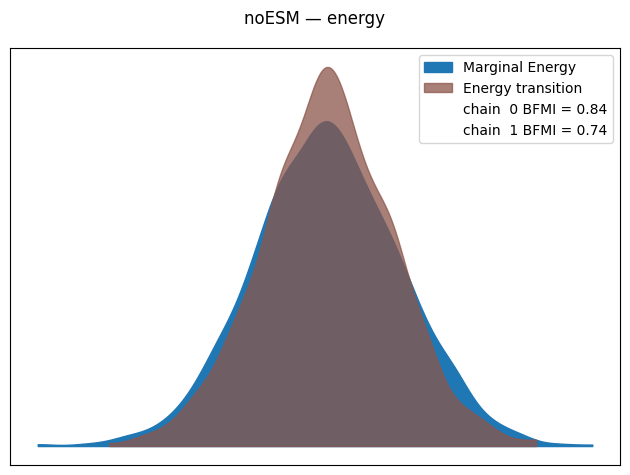

In [ ]:
diagnose_mcmc(hpmf_model_wESM_idata, label="noESM")

Parameter with worst MCMC convergence (highest r_hat=1.020): B_esm[0, 6]


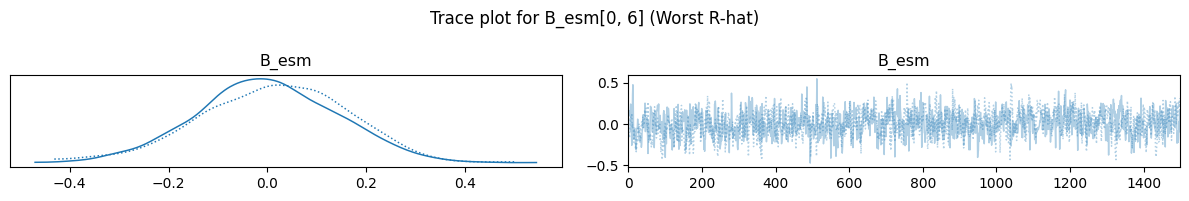

In [ ]:
import arviz as az
import matplotlib.pyplot as plt
import re

# Get the summary table for the 'noESM' model, using the provided idata
summary_wESM = az.summary(hpmf_model_wESM_idata, var_names=["sigma_obs", "B_pc", "V_species", "B_esm"])

# Filter out rows where r_hat is NaN and find the parameter with the highest r_hat
summary_filtered = summary_wESM.dropna(subset=['r_hat'])

if not summary_filtered.empty:
    worst_param_name = summary_filtered['r_hat'].idxmax()
    worst_rhat_value = summary_filtered.loc[worst_param_name, 'r_hat']
    print(f"Parameter with worst MCMC convergence (highest r_hat={worst_rhat_value:.3f}): {worst_param_name}")

    # Extract base variable name and parse indices for plotting
    match = re.match(r'([a-zA-Z_]+)(?:\[(\d+)(?:,\s*(\d+))?\])?', worst_param_name)
    base_var_name = match.group(1)
    coords = {}
    if match.group(2) is not None: # Check if first index exists
        idx1 = int(match.group(2))
        if base_var_name == "B_pc":
            coords['phys_chem'] = idx1
            if match.group(3) is not None:
                coords['latent_factor'] = int(match.group(3))
        elif base_var_name == "V_species":
            coords['species'] = idx1
            if match.group(3) is not None:
                coords['latent_factor'] = int(match.group(3))
        elif base_var_name == "B_esm":
            coords['esm'] = idx1
            if match.group(3) is not None:
                coords['latent_factor'] = int(match.group(3))

    # Plot the trace for the identified worst parameter
    az.plot_trace(hpmf_model_wESM_idata, var_names=[base_var_name], coords=coords)
    plt.suptitle(f"Trace plot for {worst_param_name} (Worst R-hat)")
    plt.tight_layout()
    plt.show()
else:
    print("No parameters with r_hat values found to plot.")

### Distribution of R-hat and ESS Values

These plots show the distribution of R-hat and Effective Sample Size (ESS) values across all parameters in the model. Ideally, R-hat values should be close to 1.0 (indicating good convergence), and ESS values should be high (indicating efficient sampling). Visualizing these distributions can quickly highlight any widespread convergence issues.

In [ ]:

hpmf_model.traceplot()

NameError: name 'hpmf_model' is not defined

In [ ]:
import arviz as az

# Display R-hat values for B_esm parameters from the full summary
# The 'summary_full' DataFrame was created in the previous cell that plotted the distributions
display(summary_full[summary_full.index.str.startswith('B_esm')].head())

# Alternatively, you can calculate R-hat directly for specific variables
rhat_b_esm = az.rhat(hpmf_model_wESM_idata, var_names='B_esm')
print("\nR-hat values for B_esm parameters (computed directly with az.rhat):\n")
display(rhat_b_esm.to_dataframe().head())

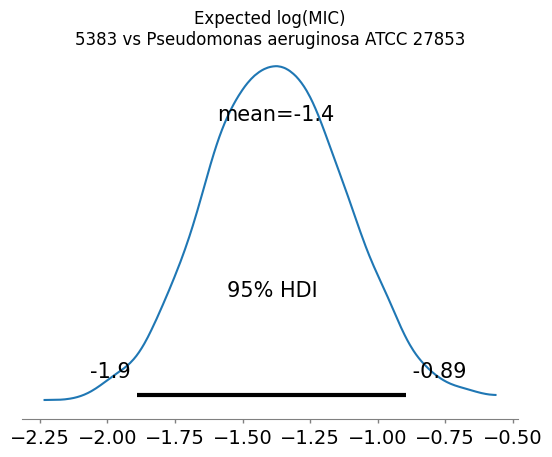

<xarray.DataArray 'x' (chain: 2, draw: 1000)> Size: 16kB
array([[-1.30295692, -1.4414812 , -1.49895397, ..., -1.14130987,
        -1.77138417, -1.22066635],
       [-1.37492425, -1.87994185, -1.2802368 , ..., -1.48210621,
        -1.34100866, -1.47667121]])
Coordinates:
  * chain    (chain) int64 16B 0 1
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
    peptide  int64 8B 341
    species  int64 8B 3

In [ ]:

hpmf_model.plot_mic_posterior(peptide_id, species_id, true_mic=None)

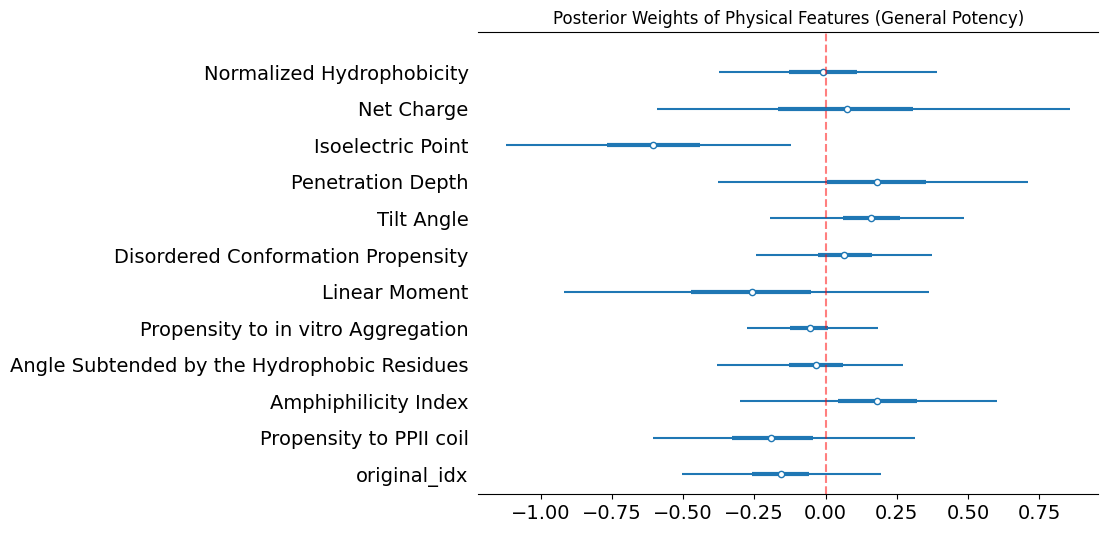

In [ ]:
# TODO check column names - missing one?
hpmf_model.plot_feature_weights()

In [ ]:

hpmf_model.plot_intercept_traces(
    species_list=top_species,
    peptide_list=test_mic['Peptide ID'].unique()[:5]
)

KeyError: np.int64(4359)

In [ ]:
def diagnose_mcmc(idata, label=""):

    # ── 1. R-hat and ESS ──────────────────────────────────
    summary = az.summary(idata, var_names=["sigma_obs", "B_pc", "V_species"])  # "global_mu"
    print(f"\n{label} — posterior summary")
    print(summary)

    bad_rhat = summary[summary["r_hat"] > 1.01]
    low_ess  = summary[summary["ess_bulk"] < 400]
    if len(bad_rhat):
        print(f"\nWARNING: {len(bad_rhat)} parameters with r_hat > 1.01")
    if len(low_ess):
        print(f"WARNING: {len(low_ess)} parameters with ESS < 400")
    else:
        print("\nMCMC looks healthy")

    # ── 2. Trace plots ────────────────────────────────────
    # az.plot_trace(idata, var_names=["global_mu", "sigma_obs"])
    # plt.suptitle(f"{label} — trace plots")
    # plt.tight_layout()
    # plt.show()

    # ── 3. Energy plot ────────────────────────────────────
    az.plot_energy(idata)
    plt.suptitle(f"{label} — energy")
    plt.tight_layout()
    plt.show()


Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)



MCMC — posterior summary
                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
sigma_obs         1.831  0.009   1.814    1.847      0.000    0.000    1015.0   
B_pc[0, 0]       -0.183  1.088  -2.225    1.738      0.147    0.038      56.0   
B_pc[0, 1]       -0.208  1.107  -2.414    1.641      0.157    0.042      50.0   
B_pc[0, 2]        0.122  1.097  -1.993    2.128      0.125    0.041      77.0   
B_pc[0, 3]        0.137  1.072  -1.807    2.217      0.172    0.067      34.0   
...                 ...    ...     ...      ...        ...      ...       ...   
V_species[19, 5] -0.009  0.028  -0.060    0.041      0.006    0.002      22.0   
V_species[19, 6]  0.004  0.029  -0.051    0.054      0.005    0.002      34.0   
V_species[19, 7] -0.009  0.032  -0.066    0.055      0.006    0.003      28.0   
V_species[19, 8] -0.010  0.031  -0.063    0.050      0.005    0.002      43.0   
V_species[19, 9]  0.005  0.032  -0.053    0.063      0.005    0.003      38.0   

 

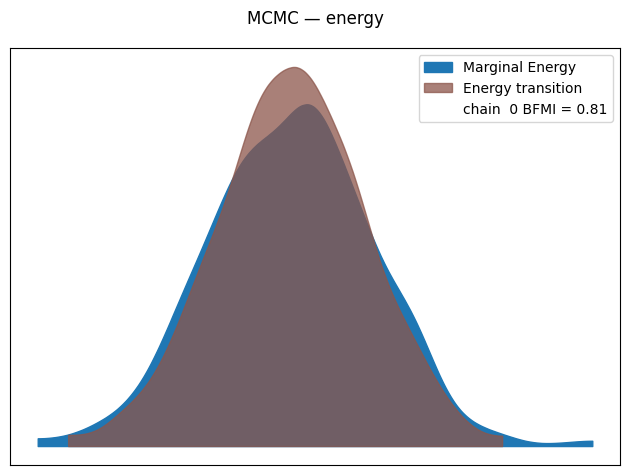

In [ ]:

# usage
diagnose_mcmc(hpmf_model.idata, label="MCMC")

In [ ]:
#Testing only on the train

# ── Strategy 1: random mask ────────────────────────────────
train_df, test_df = split_random_mask(test_mic, holdout_frac=0.20)

hpmf_model = Hybrid_PMF(train_df.copy(), all_chem_phys.iloc[:, 1:-3].copy(), all_embeddings.copy(),
                        None, dim=10, include_esm=False)
hpmf_model.draw_samples(draws=300, tune=100)

diagnose_mcmc(hpmf_model.idata, label="Strategy 1: random mask")
metrics_mask = evaluate(hpmf_model, hpmf_model.idata, test_df, all_chem_phys, all_embeddings,
                        label="Strategy 1: random mask (interpolation)")

# ── Strategy 2: held-out peptides ─────────────────────────
train_df, test_df = split_holdout_peptides(test_mic, holdout_frac=0.20)

hpmf_model = Hybrid_PMF(train_df.copy(), all_chem_phys.iloc[:, 1:-3].copy(), all_embeddings.copy(),
                        None, dim=10, include_esm=False)
hpmf_model.draw_samples(draws=300, tune=100)

diagnose_mcmc(hpmf_model.idata, label="Strategy 2: held-out peptides")
metrics_holdout = evaluate(hpmf_model, hpmf_model.idata, test_df, all_chem_phys, all_embeddings,
                           label="Strategy 2: held-out peptides (generalization)")

In [ ]:
# ── Full dataset (all species) ─────────────────────────────
peptides_w_data = list(set(full_mic_data['Peptide ID']) & set(all_chem_phys.index))
has_data_noDup  = full_mic_data[full_mic_data['Peptide ID'].isin(peptides_w_data)].drop_duplicates(['Peptide ID', 'Target Species'])
full_mic        = has_data_noDup[['Peptide ID', 'Target Species', 'Activity']].dropna()
full_mic        = full_mic[full_mic["Activity"].astype(str).str.match("^[0-9.]+$", na=False)]
full_mic['mic'] = full_mic['Activity'].astype(float)

# ── Strategy 1: random mask ────────────────────────────────
train_df, test_df = split_random_mask(full_mic, holdout_frac=0.20)

hpmf_model = Hybrid_PMF(train_df.copy(), all_chem_phys.iloc[:, 1:-3].copy(), all_embeddings.copy(),
                        None, dim=10, include_esm=False)
approx = hpmf_model.var_inference(n=10000)
hpmf_model.idata = approx.sample(2000)

metrics_mask = evaluate(hpmf_model, hpmf_model.idata, test_df, all_chem_phys, all_embeddings,
                        label="Strategy 1: random mask (interpolation)")

# ── Strategy 2: held-out peptides ─────────────────────────
train_df, test_df = split_holdout_peptides(full_mic, holdout_frac=0.20)

hpmf_model = Hybrid_PMF(train_df.copy(), all_chem_phys.iloc[:, 1:-3].copy(), all_embeddings.copy(),
                        None, dim=10, include_esm=False)
approx = hpmf_model.var_inference(n=10000)
hpmf_model.idata = approx.sample(2000)

metrics_holdout = evaluate(hpmf_model, hpmf_model.idata, test_df, all_chem_phys, all_embeddings,
                           label="Strategy 2: held-out peptides (generalization)")

In [ ]:
_traceplot(hpmf_model)

NameError: name '_traceplot' is not defined

# VI

In [ ]:
with model.model as model:
  approx = pm.fit()

Output()

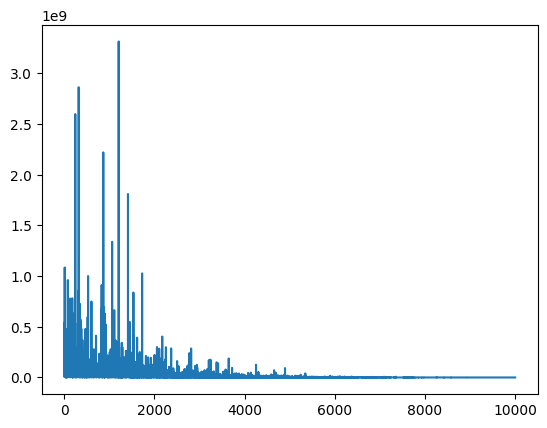

In [ ]:

plt.plot(approx.hist)

In [ ]:
import arviz as az

with model as model:
    idata = approx.sample(1000)

In [ ]:

az.summary(idata, kind="stats")


,mean,sd,hdi_3%,hdi_97%
"B_esm[0, 0]",0.013,1.014,-1.546,1.949
"B_esm[0, 1]",-0.059,0.986,-1.416,1.427
"B_esm[0, 2]",-0.031,0.948,-1.680,1.875
"B_esm[0, 3]",-0.011,1.039,-1.824,1.488
"B_esm[0, 4]",0.050,0.863,-1.356,1.648
...,...,...,...,...
w0_pc[7],-0.000,0.673,-1.119,1.446
w0_pc[8],-0.006,0.207,-0.391,0.380
w0_pc[9],0.007,0.260,-0.458,0.490
w0_pc[10],0.025,0.674,-1.256,1.236


/usr/local/lib/python3.12/dist-packages/arviz/plots/backends/matplotlib/pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


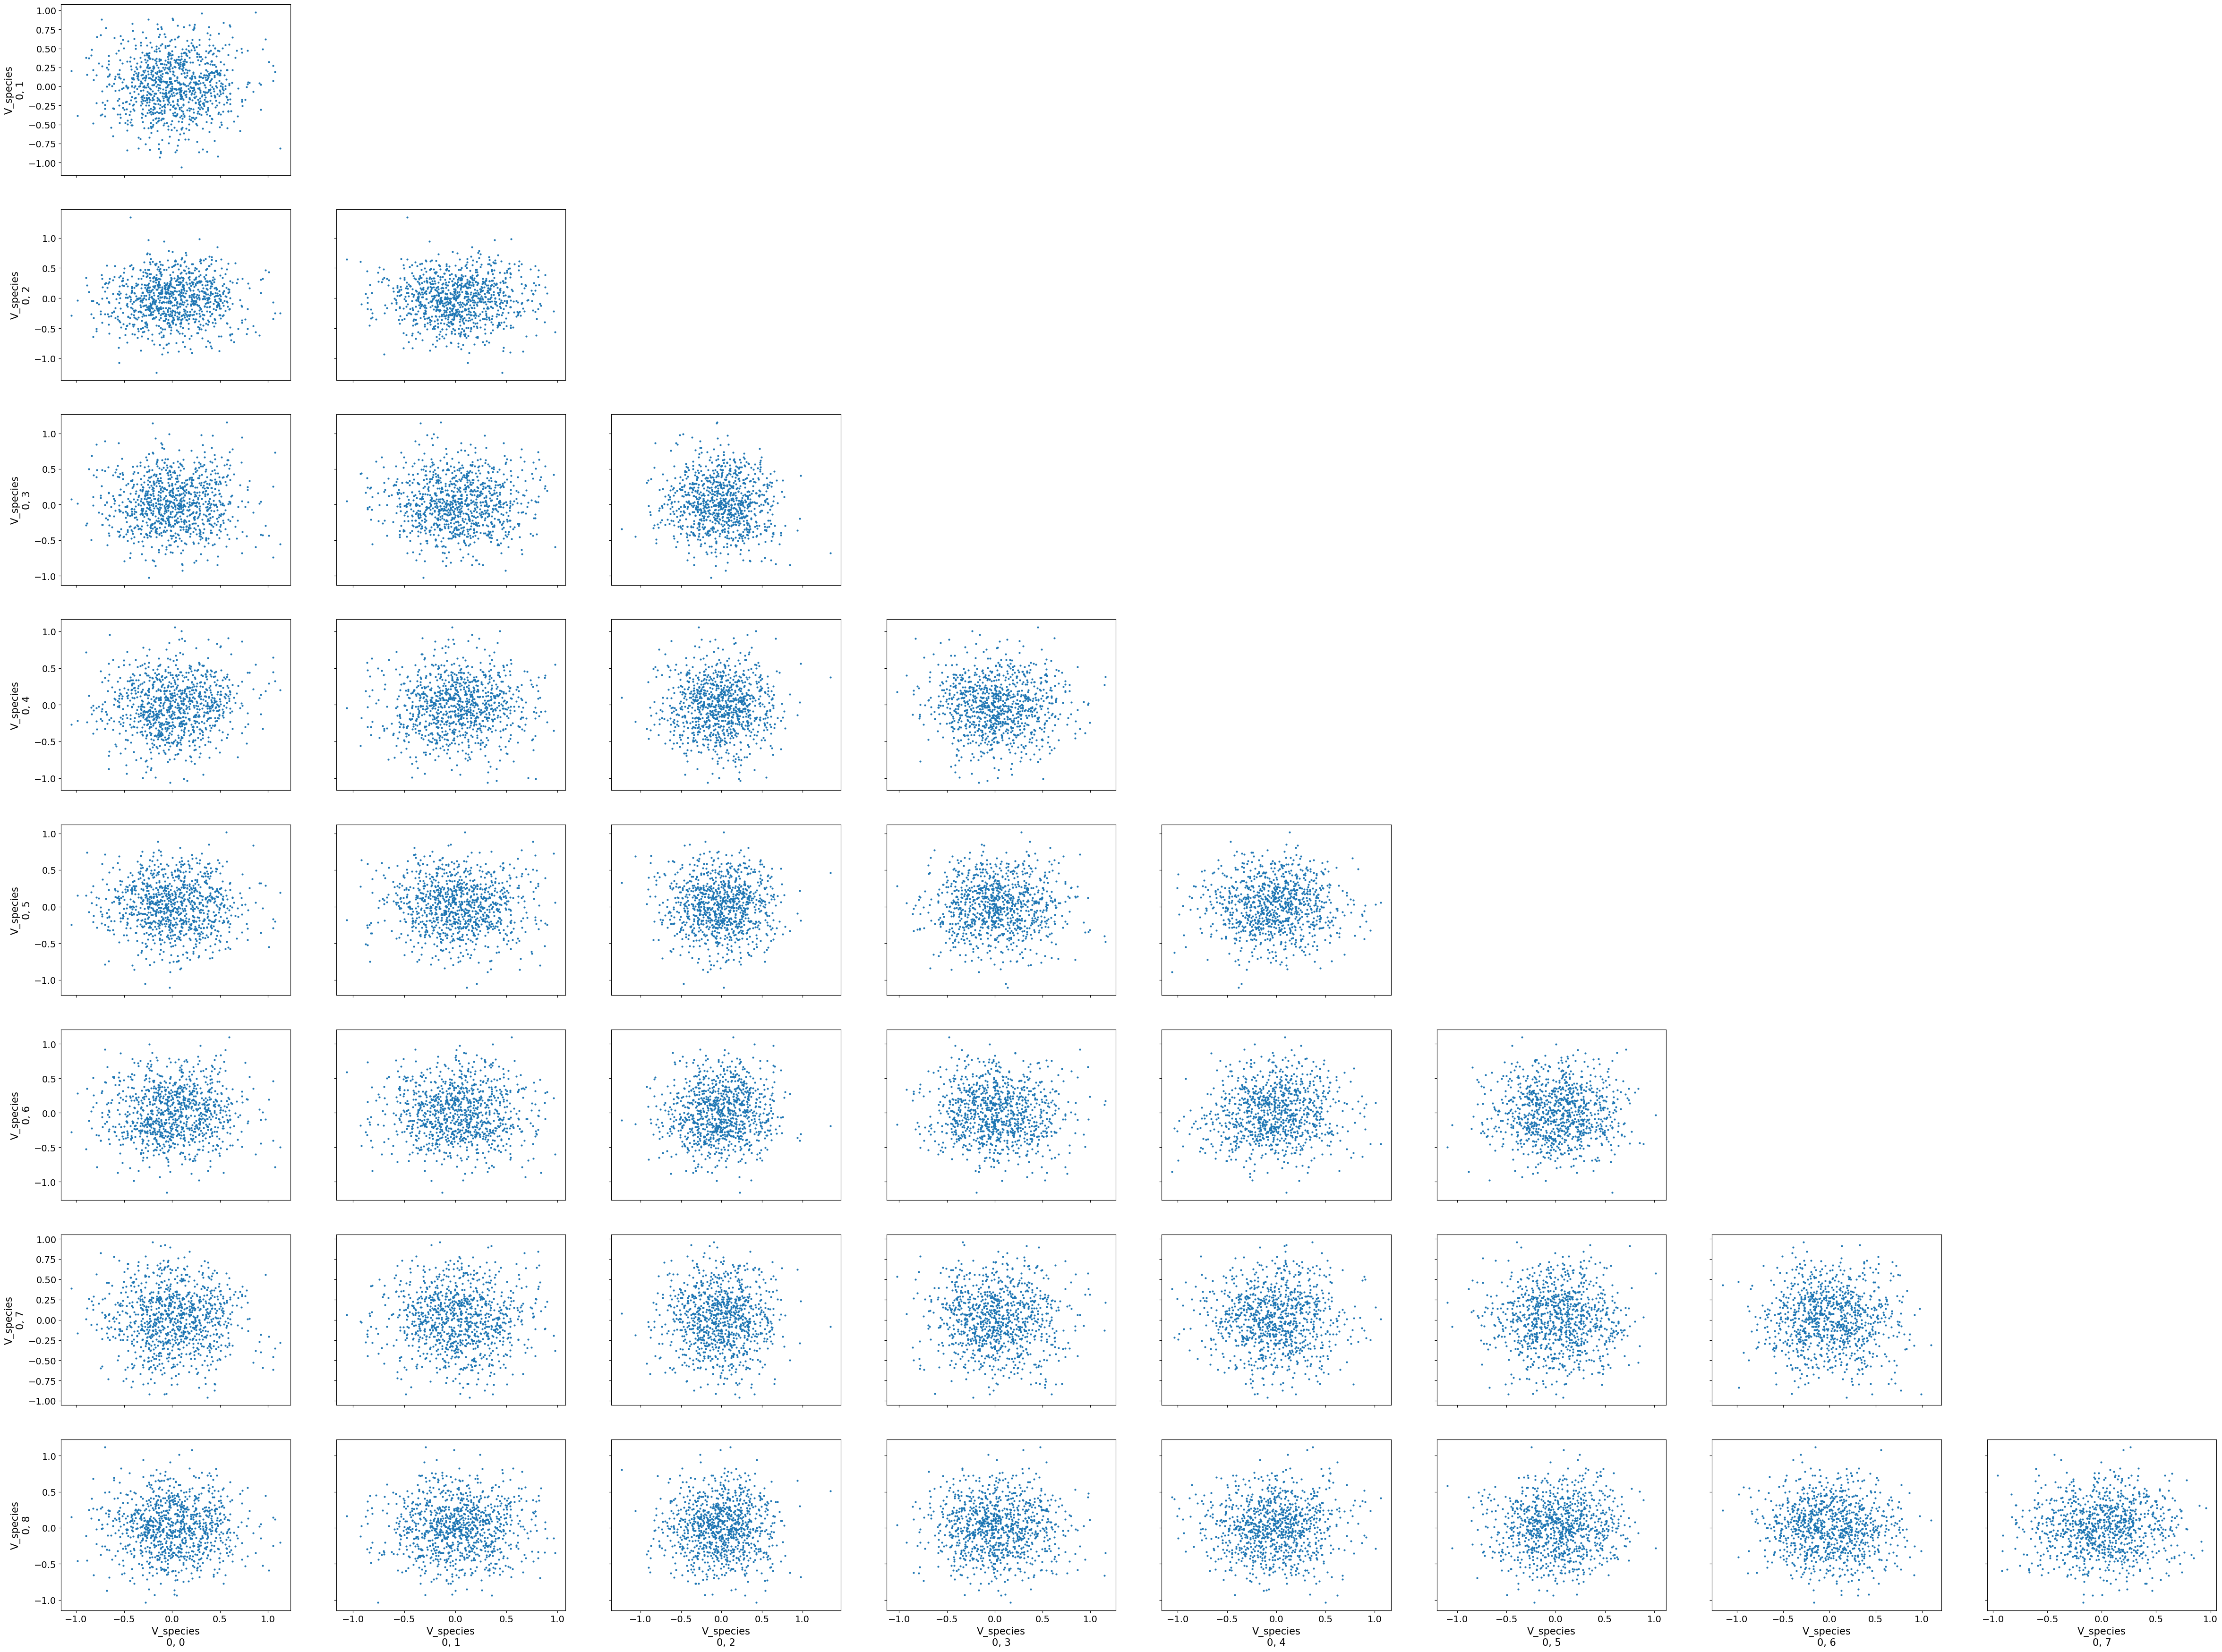

In [ ]:

az.plot_pair(idata, var_names="V_species", coords={"species": [0, 2]});

In [ ]:

hpmf_model.strain_dict

{'Escherichia coli ATCC 25922': 0,
 'Staphylococcus aureus ATCC 25923': 1,
 'Pseudomonas aeruginosa ATCC 27853': 2}

In [ ]:

tmp_predict = test_mic.iloc[1:4].copy()

In [ ]:

all_chem_phys.loc[tmp_predict['Peptide ID']].iloc[:, 1:13].values

array([[  0.96,  -0.41,   3.  ,  10.7 ,  16.  ,  90.  ,   0.29,   0.19,
          3.02, 100.  ,   0.65,   0.87],
       [  0.98,  -0.43,   3.  ,  10.7 ,  23.  ,  44.  ,   0.3 ,   0.19,
          3.02, 100.  ,   0.65,   0.89],
       [  0.98,  -0.43,   3.  ,  10.7 ,  23.  ,  44.  ,   0.3 ,   0.19,
          3.02, 100.  ,   0.65,   0.89]])

In [ ]:

with hpmf_model.model:
    # change the value and shape of the data
    pm.set_data(
        {
            "pep_idx": [1000, 1001, 1002],
            # use dummy values with the same shape:
            "spec_idx": tmp_predict['Target Species'].map(hpmf_model.strain_dict),
            "mic": [False, False, False],
            "X_pc": all_chem_phys.loc[tmp_predict['Peptide ID']].iloc[:, 1:13].values,
            "X_esm": all_embeddings.loc[tmp_predict['Peptide ID']].values,
        },
        coords={"idx": [1001, 1002, 1003]},
    )

    pm.sample_posterior_predictive(idata, extend_inferencedata=True)

ValueError: The 'pep_idx' variable already had 893 coord values defined for its obs_id dimension. With the new values this dimension changes to length 3, so new coord values for the obs_id dimension are required.

In [ ]:

tmp_predict['Activity']

In [ ]:
idata.posterior_predictive["obs"].mean(dim=["draw", "chain"])

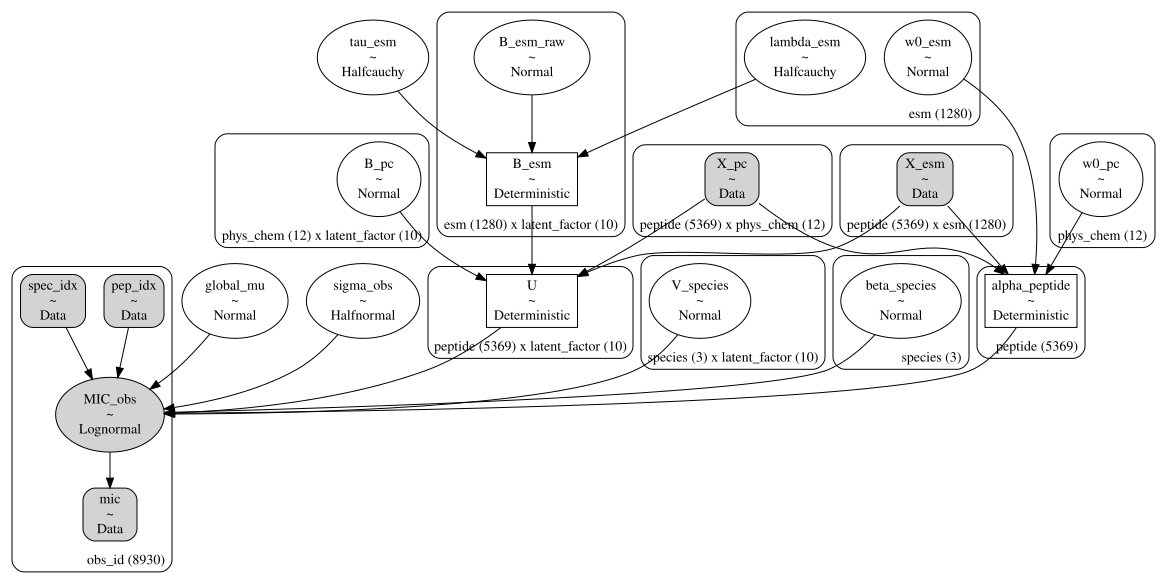

In [ ]:

pm.model_to_graphviz(model.model)

In [ ]:
#Vi vs MCMC comparison defunct bc VI takes so long

import arviz as az
import matplotlib.pyplot as plt

# ── 0. Verify MCMC converged before comparing ─────────────
summary = az.summary(idata_mcmc, var_names=["global_mu", "sigma_obs", "B_pc", "V_species"])
bad_rhat = summary[summary["r_hat"] > 1.01]
low_ess  = summary[summary["ess_bulk"] < 400]

if len(bad_rhat) or len(low_ess):
    print("WARNING: MCMC may not have converged — comparison with VI is unreliable")
    print(f"  {len(bad_rhat)} parameters with r_hat > 1.01")
    print(f"  {len(low_ess)} parameters with ESS < 400")
else:
    print("MCMC looks healthy — proceeding with comparison")

az.plot_trace(idata_mcmc, var_names=["global_mu", "sigma_obs"])
plt.tight_layout()
plt.show()

# ── 1. Compare metrics on test set ────────────────────────
metrics_mcmc = evaluate(model_mcmc, idata_mcmc, test_df, all_chem_phys, all_embeddings,
                        label="MCMC - held-out peptides")
metrics_vi   = evaluate(model_vi,   idata_vi,   test_df, all_chem_phys, all_embeddings,
                        label="VI   - held-out peptides")

print("\nMetric comparison:")
print(f"{'':20s}  {'MCMC':>10s}  {'VI':>10s}")
for k in ["rmse", "pearson_r", "spearman_r"]:
    print(f"  {k:18s}  {metrics_mcmc[k]:>10.4f}  {metrics_vi[k]:>10.4f}")


# ── 2. Compare posterior means of key parameters ──────────
print("\nMCMC posterior summary:")
print(az.summary(idata_mcmc, var_names=["global_mu", "sigma_obs", "B_pc"]))

print("\nVI posterior summary:")
print(az.summary(idata_vi,   var_names=["global_mu", "sigma_obs", "B_pc"]))


# ── 3. Plot posterior distributions side by side ──────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, var in zip(axes, ["global_mu", "sigma_obs"]):
    az.plot_posterior(idata_mcmc, var_names=[var], ax=ax, color="steelblue", label="MCMC")
    az.plot_posterior(idata_vi,   var_names=[var], ax=ax, color="coral",     label="VI")
    ax.set_title(var)
    ax.legend()

# B_pc: compare distribution of all weights as a histogram
ax = axes[2]
ax.hist(idata_mcmc.posterior["B_pc"].values.flatten(), bins=50,
        alpha=0.5, color="steelblue", label="MCMC", density=True)
ax.hist(idata_vi.posterior["B_pc"].values.flatten(),   bins=50,
        alpha=0.5, color="coral",     label="VI",   density=True)
ax.set_title("B_pc (all weights)")
ax.legend()

plt.suptitle("MCMC vs VI posterior comparison")
plt.tight_layout()
plt.show()